# Digital Payments Settlement Latency & Merchant Churn Analytics
### Group 03 — Programming for Analytics · Comprehensive Group Capstone Project & Live Code Defense

**Engagement framing:** Senior Analytics Advisory Team reporting to the **COO** and **Head of Merchant Acquiring**
of a digital payments aggregator processing 530k+ monthly-scale transaction volume across UPI, Cards and
NetBanking for 8,500+ merchants (revenue = Merchant Discount Rate on processed volume).

| # | Team Member | SAP ID | Roll Number | Email ID | % Contribution |
|---|-------------|--------|-------------|----------|----------------|
| 1 | *Member A (add name)* | *SAP ID* | *Roll No* | *email@institution.edu* | 100% |
| 2 | *Member B (add name)* | *SAP ID* | *Roll No* | *email@institution.edu* | 100% |
| 3 | *Member C (add name)* | *SAP ID* | *Roll No* | *email@institution.edu* | 100% |
| 4 | *Member D (add name)* | *SAP ID* | *Roll No* | *email@institution.edu* | 100% |
| 5 | *Member E (add name)* | *SAP ID* | *Roll No* | *email@institution.edu* | 100% |
| 6 | *Member F (add name)* | *SAP ID* | *Roll No* | *email@institution.edu* | 100% |
| 7 | *Member G (add name)* | *SAP ID* | *Roll No* | *email@institution.edu* | 100% |

**Data:** `payments_analytics.db` (SQLite 3) — 5 relational tables (3 dimensions, 2 facts), sole data source.
**Notebook map:** setup → schema & integrity → data quality → analytical prep → descriptive baseline →
Part 1 gateway diagnostics (KBQ 1–2) → Part 2 settlement & churn (KBQ 3–4) → Part 3 smart-routing lift (KBQ 5–6) →
Part 4 revenue economics (KBQ 7–8) → findings, 5 recommendations & executive summary.

**How to run:** keep this notebook beside `payments_analytics.db` and run *Restart Kernel → Run All Cells*.
Python ≥ 3.13 with `pandas`, `sqlalchemy`, `matplotlib` (see `requirements.txt`; uv users: `uv sync`).
All paths are relative — no configuration needed.

## 1 · Setup & Configuration
One environment cell: imports, display/plot settings, the read-only SQL helper (`run_sql`) that pushes
aggregation down to SQLite, and small formatting utilities used throughout.

In [1]:
# Core libraries
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, text

warnings.filterwarnings("ignore")          # keep outputs clean for evaluation
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 170)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

plt.rcParams.update({
    "figure.dpi": 110,
    "figure.figsize": (9.5, 4.2),
    "axes.grid": True,
    "grid.alpha": 0.30,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "font.size": 9.5,
})

# --- database connection (RELATIVE path — the .db must sit beside this notebook) ---
DB_PATH = Path("payments_analytics.db")
assert DB_PATH.exists(), f"Database not found at {DB_PATH.resolve()} — keep payments_analytics.db beside this notebook."
engine = create_engine(f"sqlite:///{DB_PATH}")

TIER_ORDER = ["ENTERPRISE", "MID_MARKET", "SMB"]
TIER_COLORS = {"ENTERPRISE": "#1f77b4", "MID_MARKET": "#ff7f0e", "SMB": "#d62728"}


def run_sql(sql: str) -> pd.DataFrame:
    """Run a read-only SQL query against the analytics DB (aggregation pushed down to SQLite)."""
    with engine.connect() as conn:
        return pd.read_sql(text(sql), conn)


def label_bars(ax, fmt="{:,.0f}"):
    """Value labels on top of vertical bars."""
    ymax = max((p.get_height() for p in ax.patches), default=0)
    for p in ax.patches:
        ax.annotate(fmt.format(p.get_height()),
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha="center", va="bottom", fontsize=8, xytext=(0, 2),
                    textcoords="offset points")


def inrm(x, decimals=2):
    """Format an INR amount in millions."""
    return f"Rs {x/1e6:,.{decimals}f}M"


print("Environment ready — python pandas", pd.__version__,
      "| DB:", DB_PATH.name, "| exists:", DB_PATH.exists())

Environment ready — python pandas 3.0.5 | DB: payments_analytics.db | exists: True


## 2 · Relational Schema Inspection & Integrity Validation
The database is a star-like schema: **3 dimensions** (`dim_merchants`, `dim_issuing_banks`,
`dim_payment_methods`) → **2 facts** (`fact_payment_transactions`, `fact_merchant_settlements`),
all FKs `ON DELETE RESTRICT`. We verify: row counts, PK uniqueness, FK orphan-ness, join fan-out
(1:N / N:M-through-facts) and the settlement ledger identity
`net_settled_amount_inr = gross_volume_inr − net_mdr_deducted_inr`.

In [2]:
# --- inventory: tables, row counts, declared PKs and FKs ---
inventory = run_sql("""
    SELECT name, type FROM sqlite_master WHERE type = 'table' ORDER BY name
""")
row_counts = {}
for t in inventory["name"]:
    row_counts[t] = run_sql(f"SELECT COUNT(*) AS n FROM {t}")["n"].iloc[0]
display(pd.DataFrame({"table": list(row_counts), "rows": list(row_counts.values())}))

fk_map = run_sql("""
    SELECT m.name AS child_table, f.'from' AS fk_column, f.'table' AS parent_table, f.'to' AS pk_column
    FROM sqlite_master m
    JOIN pragma_foreign_key_list(m.name) f
    WHERE m.type = 'table'
    ORDER BY child_table
""")
print("\nDeclared relationships (all ON DELETE RESTRICT):")
display(fk_map)

,table,rows
0,dim_issuing_banks,12
1,dim_merchants,8500
2,dim_payment_methods,16
3,fact_merchant_settlements,125000
4,fact_payment_transactions,530000



Declared relationships (all ON DELETE RESTRICT):


,child_table,fk_column,parent_table,pk_column
0,fact_merchant_settlements,merchant_id,dim_merchants,merchant_id
1,fact_payment_transactions,payment_method_id,dim_payment_methods,payment_method_id
2,fact_payment_transactions,bank_id,dim_issuing_banks,bank_id
3,fact_payment_transactions,merchant_id,dim_merchants,merchant_id


In [3]:
# --- PK uniqueness (no duplicate primary keys) ---
pk_checks = {
    "dim_merchants": "merchant_id",
    "dim_issuing_banks": "bank_id",
    "dim_payment_methods": "payment_method_id",
    "fact_payment_transactions": "txn_id",
    "fact_merchant_settlements": "settlement_id",
}
dup_pk = pd.DataFrame([
    {"table": t, "duplicate_pks": run_sql(
        f"SELECT COUNT(*) AS n FROM (SELECT {k} FROM {t} GROUP BY {k} HAVING COUNT(*) > 1)")["n"].iloc[0]}
    for t, k in pk_checks.items()
])
display(dup_pk)
assert dup_pk["duplicate_pks"].sum() == 0, "Duplicate primary keys found!"

# --- FK orphan checks (join integrity) ---
orphan_sql = """
    SELECT COUNT(*) AS orphans FROM {child} c
    LEFT JOIN {parent} p ON c.{fk} = p.{pk}
    WHERE p.{pk} IS NULL
"""
orphan_checks = pd.DataFrame([
    {"relationship": f"{c}.{f} -> {p}", "orphans": run_sql(
        orphan_sql.format(child=c, parent=p, fk=f, pk=k))["orphans"].iloc[0]}
    for c, p, f, k in [
        ("fact_payment_transactions", "dim_merchants", "merchant_id", "merchant_id"),
        ("fact_payment_transactions", "dim_issuing_banks", "bank_id", "bank_id"),
        ("fact_payment_transactions", "dim_payment_methods", "payment_method_id", "payment_method_id"),
        ("fact_merchant_settlements", "dim_merchants", "merchant_id", "merchant_id"),
    ]
])
display(orphan_checks)
assert orphan_checks["orphans"].sum() == 0, "Orphaned FK records found!"

# --- settlement ledger identity ---
bad_ledger = run_sql("""
    SELECT COUNT(*) AS violations
    FROM fact_merchant_settlements
    WHERE ABS(net_settled_amount_inr - (gross_volume_inr - net_mdr_deducted_inr)) > 0.01
""")["violations"].iloc[0]
print(f"Ledger identity violations (net ≠ gross − MDR, tolerance Rs 0.01): {bad_ledger}")
assert bad_ledger == 0, "Settlement ledger identity broken!"

# --- fan-out sanity: one merchant can have many txns & settlements (1:N); merchant × bank × method meet in the fact (N:M) ---
fanout = run_sql("""
    SELECT 'txns per merchant' AS relationship, MAX(n) AS max_per_key, ROUND(AVG(n), 1) AS avg_per_key
    FROM (SELECT merchant_id, COUNT(*) n FROM fact_payment_transactions GROUP BY merchant_id)
    UNION ALL
    SELECT 'settlements per merchant', MAX(n), ROUND(AVG(n), 1)
    FROM (SELECT merchant_id, COUNT(*) n FROM fact_merchant_settlements GROUP BY merchant_id)
    UNION ALL
    SELECT 'banks per merchant (via txns)', MAX(n), ROUND(AVG(n), 1)
    FROM (SELECT merchant_id, COUNT(DISTINCT bank_id) n FROM fact_payment_transactions GROUP BY merchant_id)
    UNION ALL
    SELECT 'methods per merchant (via txns)', MAX(n), ROUND(AVG(n), 1)
    FROM (SELECT merchant_id, COUNT(DISTINCT payment_method_id) n FROM fact_payment_transactions GROUP BY merchant_id)
""")
display(fanout)
print("VERDICT: schema is a clean star schema — PKs unique, zero orphans, ledger identity holds; "
      "facts bridge dimensions 1:N with N:M analysis available merchant×bank×method.")

,table,duplicate_pks
0,dim_merchants,0
1,dim_issuing_banks,0
2,dim_payment_methods,0
3,fact_payment_transactions,0
4,fact_merchant_settlements,0


,relationship,orphans
0,fact_payment_transactions.merchant_id -> dim_m...,0
1,fact_payment_transactions.bank_id -> dim_issui...,0
2,fact_payment_transactions.payment_method_id ->...,0
3,fact_merchant_settlements.merchant_id -> dim_m...,0


Ledger identity violations (net ≠ gross − MDR, tolerance Rs 0.01): 0


,relationship,max_per_key,avg_per_key
0,txns per merchant,91,62.40
1,settlements per merchant,73,49.70
2,banks per merchant (via txns),12,11.90
3,methods per merchant (via txns),16,13.00


VERDICT: schema is a clean star schema — PKs unique, zero orphans, ledger identity holds; facts bridge dimensions 1:N with N:M analysis available merchant×bank×method.


## 3 · Data Quality Audit & Treatment Decisions
Systematic checks: NULL patterns, duplicate business keys, categorical domain conformance, referential
date ranges, and value-plausibility bounds. Every **material decision** taken later in the notebook is
justified by a check below.

In [4]:
# --- NULL audit (all tables) ---
null_rows = []
for t, cols in {
    "dim_merchants": ["merchant_id", "mcc_category", "onboarding_date", "merchant_tier",
                      "settlement_cycle_sla", "is_active", "churn_date", "churn_reason"],
    "dim_issuing_banks": ["bank_id", "bank_name", "tier", "base_network_reliability_pct"],
    "dim_payment_methods": ["payment_method_id", "payment_channel", "network_provider", "mdr_rate_pct"],
    "fact_payment_transactions": ["txn_id", "merchant_id", "bank_id", "payment_method_id",
                                  "txn_timestamp", "amount_inr", "status", "error_code",
                                  "latency_ms", "is_routed_via_dynamic_sla"],
    "fact_merchant_settlements": ["settlement_id", "merchant_id", "settlement_batch_date",
                                  "gross_volume_inr", "net_mdr_deducted_inr", "net_settled_amount_inr",
                                  "expected_settlement_date", "actual_settlement_date",
                                  "settlement_delay_days", "sla_breach_flag"],
}.items():
    n_total = row_counts[t]
    for c in cols:
        n_null = run_sql(f'SELECT COUNT(*) AS n FROM {t} WHERE "{c}" IS NULL')["n"].iloc[0]
        if n_null:
            null_rows.append({"table": t, "column": c, "nulls": n_null, "null_pct": 100 * n_null / n_total})
nulls_df = pd.DataFrame(null_rows).sort_values("null_pct", ascending=False)
display(nulls_df if len(nulls_df) else pd.DataFrame({"result": ["no NULLs anywhere"]}))

# churn fields are NULL **by design** for active merchants — verify the pattern:
churn_nulls = run_sql("""
    SELECT CASE WHEN is_active = 1 THEN 'active' ELSE 'churned' END AS merchant_state,
           COUNT(*) AS merchants,
           SUM(churn_date IS NULL) AS churn_date_nulls,
           SUM(churn_reason IS NULL) AS churn_reason_nulls
    FROM dim_merchants GROUP BY 1
""")
display(churn_nulls)

,table,column,nulls,null_pct
0,dim_merchants,churn_date,7122,83.79
1,dim_merchants,churn_reason,7122,83.79


,merchant_state,merchants,churn_date_nulls,churn_reason_nulls
0,active,7122,7122,7122
1,churned,1378,0,0


In [5]:
# --- categorical domain conformance + pairing logic ---
domain_checks = {
    "txn status in {SUCCESS, FAILED, USER_DROPPED, TIMEOUT}": run_sql("""
        SELECT COUNT(*) n FROM fact_payment_transactions
        WHERE status NOT IN ('SUCCESS', 'FAILED', 'USER_DROPPED', 'TIMEOUT')"""),
    "txn error_code in declared 6-value domain": run_sql("""
        SELECT COUNT(*) n FROM fact_payment_transactions
        WHERE error_code NOT IN ('ERR_NONE', 'ERR_BANK_TIMEOUT', 'ERR_INSUFFICIENT_FUNDS',
                                 'ERR_NPCI_DEGRADED', 'ERR_AUTH_FAILED', 'ERR_SWITCH_UNAVAILABLE')"""),
    "SUCCESS <=> ERR_NONE pairing": run_sql("""
        SELECT COUNT(*) n FROM fact_payment_transactions
        WHERE (status = 'SUCCESS') <> (error_code = 'ERR_NONE')"""),
    "sla_breach_flag in {0,1}": run_sql("""
        SELECT COUNT(*) n FROM fact_merchant_settlements WHERE sla_breach_flag NOT IN (0, 1)"""),
    "settlement_delay_days >= 0": run_sql("""
        SELECT COUNT(*) n FROM fact_merchant_settlements WHERE settlement_delay_days < 0"""),
    "latency_ms in plausible range (250-12000)": run_sql("""
        SELECT COUNT(*) n FROM fact_payment_transactions
        WHERE latency_ms < 250 OR latency_ms > 12000"""),
    "amount_inr > 0": run_sql("""
        SELECT COUNT(*) n FROM fact_payment_transactions WHERE amount_inr <= 0"""),
    "merchant tier in {ENTERPRISE, MID_MARKET, SMB}": run_sql("""
        SELECT COUNT(*) n FROM dim_merchants
        WHERE merchant_tier NOT IN ('ENTERPRISE', 'MID_MARKET', 'SMB')"""),
    "churn_reason NULL exactly when active": run_sql("""
        SELECT COUNT(*) n FROM dim_merchants
        WHERE (is_active = 1) <> (churn_reason IS NULL)"""),
    "is_active consistent with churn_date": run_sql("""
        SELECT COUNT(*) n FROM dim_merchants
        WHERE (churn_date IS NOT NULL) AND is_active = 1"""),
}
domain_df = pd.DataFrame(
    [{"check": k, "violations": int(v["n"].iloc[0])} for k, v in domain_checks.items()])
display(domain_df)
assert domain_df["violations"].sum() == 0, "Domain violations found!"

# --- temporal coverage ---
ranges = run_sql("""
    SELECT 'transactions' AS series, MIN(txn_timestamp) AS first_ts, MAX(txn_timestamp) AS last_ts,
           COUNT(DISTINCT SUBSTR(txn_timestamp, 1, 7)) AS months
    FROM fact_payment_transactions
    UNION ALL
    SELECT 'settlement batches', MIN(settlement_batch_date), MAX(settlement_batch_date),
           COUNT(DISTINCT SUBSTR(settlement_batch_date, 1, 7))
    FROM fact_merchant_settlements
    UNION ALL
    SELECT 'settlement actual dates', MIN(actual_settlement_date), MAX(actual_settlement_date),
           COUNT(DISTINCT SUBSTR(actual_settlement_date, 1, 7))
    FROM fact_merchant_settlements
    UNION ALL
    SELECT 'merchant onboarding', MIN(onboarding_date), MAX(onboarding_date),
           COUNT(DISTINCT SUBSTR(onboarding_date, 1, 7))
    FROM dim_merchants
""")
display(ranges)

spillover = run_sql("""
    SELECT SUBSTR(actual_settlement_date, 1, 7) AS settle_month,
           COUNT(*) AS batches, SUM(sla_breach_flag) AS breaches
    FROM fact_merchant_settlements
    GROUP BY 1 ORDER BY 1 DESC LIMIT 3
""")
display(spillover)

,check,violations
0,"txn status in {SUCCESS, FAILED, USER_DROPPED, ...",0
1,txn error_code in declared 6-value domain,0
2,SUCCESS <=> ERR_NONE pairing,0
3,"sla_breach_flag in {0,1}",0
4,settlement_delay_days >= 0,0
5,latency_ms in plausible range (250-12000),0
6,amount_inr > 0,0
7,"merchant tier in {ENTERPRISE, MID_MARKET, SMB}",0
8,churn_reason NULL exactly when active,0
9,is_active consistent with churn_date,0


,series,first_ts,last_ts,months
0,transactions,2023-07-01 00:00:24,2024-12-31 23:58:13,18
1,settlement batches,2023-07-01,2024-12-31,18
2,settlement actual dates,2023-07-01,2025-01-07,19
3,merchant onboarding,2023-01-01,2024-06-30,18


,settle_month,batches,breaches
0,2025-01,438,221
1,2024-12,7019,2058
2,2024-11,6703,1947


In [6]:
# --- documented quality decisions ---
from IPython.display import Markdown, display as ipy_display

stub_month = spillover["settle_month"].iloc[0]
stub_batches = int(spillover["batches"].iloc[0])

# coverage of the settlement fact — does partial coverage select on churn?
parity = run_sql("""
    SELECT CASE WHEN merchant_id IN (SELECT merchant_id FROM fact_merchant_settlements)
                THEN 'covered' ELSE 'not covered' END AS grp,
           COUNT(*) AS merchants, AVG(churn_date IS NOT NULL) * 100 AS churn_pct
    FROM dim_merchants GROUP BY 1
""")

ipy_display(Markdown(f"""\
**Data-quality findings & treatment decisions**

| # | Finding (verified above) | Decision & rationale |
|---|--------------------------|----------------------|
| Q1 | Only NULLs in the entire DB: `churn_date` / `churn_reason` for the {int(churn_nulls.loc[churn_nulls['merchant_state'] == 'active', 'merchants'].iloc[0]):,} active merchants | **Keep as-is** — structurally meaningful NULLs (active merchants never churned). Imputation would be wrong. |
| Q2 | Zero duplicate PKs, zero FK orphans, settlement ledger identity exact | No de-duplication or repair needed; keyed joins are safe (no Cartesian inflation risk). |
| Q3 | `status` uses the 4-value domain incl. `USER_DROPPED`; `SUCCESS ⇔ ERR_NONE` pairs perfectly | Treat the dictionary's 4-value domain as authoritative. Success rate = SUCCESS ÷ all attempts (per brief). |
| Q4 | Settlement `actual_settlement_date` spills into a **stub month {stub_month}** ({stub_batches:,} late-settled T+2/T+3 batches) | **Keep rows** (valid settlements) but cut monthly trend series at 2024-12; annualization uses the clean 18-month window 2023-07 → 2024-12. |
| Q5 | Latency bounded 250–12,000 ms by design; amounts strictly positive; breach flags binary; delay days ≥ 0 | Bounds respected — no winsorization applied (values are physically plausible). |
| Q6 | Settlement fact covers only **{int(parity.loc[parity['grp'] == 'covered', 'merchants'].iloc[0]):,} of {int(parity['merchants'].sum()):,} merchants**; covered vs uncovered churn nearly identical ({parity.loc[parity['grp'] == 'covered', 'churn_pct'].iloc[0]:.2f}% vs {parity.loc[parity['grp'] == 'not covered', 'churn_pct'].iloc[0]:.2f}%) | Exposure→churn analysis is run **within the covered population** (Part 2/Part 4) — coverage does not select on churn, so comparisons remain unbiased; the gap is stated wherever settlement-based figures appear. |"""))

**Data-quality findings & treatment decisions**

| # | Finding (verified above) | Decision & rationale |
|---|--------------------------|----------------------|
| Q1 | Only NULLs in the entire DB: `churn_date` / `churn_reason` for the 7,122 active merchants | **Keep as-is** — structurally meaningful NULLs (active merchants never churned). Imputation would be wrong. |
| Q2 | Zero duplicate PKs, zero FK orphans, settlement ledger identity exact | No de-duplication or repair needed; keyed joins are safe (no Cartesian inflation risk). |
| Q3 | `status` uses the 4-value domain incl. `USER_DROPPED`; `SUCCESS ⇔ ERR_NONE` pairs perfectly | Treat the dictionary's 4-value domain as authoritative. Success rate = SUCCESS ÷ all attempts (per brief). |
| Q4 | Settlement `actual_settlement_date` spills into a **stub month 2025-01** (438 late-settled T+2/T+3 batches) | **Keep rows** (valid settlements) but cut monthly trend series at 2024-12; annualization uses the clean 18-month window 2023-07 → 2024-12. |
| Q5 | Latency bounded 250–12,000 ms by design; amounts strictly positive; breach flags binary; delay days ≥ 0 | Bounds respected — no winsorization applied (values are physically plausible). |
| Q6 | Settlement fact covers only **2,517 of 8,500 merchants**; covered vs uncovered churn nearly identical (16.09% vs 16.26%) | Exposure→churn analysis is run **within the covered population** (Part 2/Part 4) — coverage does not select on churn, so comparisons remain unbiased; the gap is stated wherever settlement-based figures appear. |

## 4 · Analytical Preparation (push-down to SQL)
Domain conventions used throughout — all heavy grouping is executed **inside SQLite**; Python receives
small result frames. The merchant-level breach-rate CTE below is reused by Part 2 (churn) and Part 4
(protected volume) so both parts share one consistent definition.

In [7]:
# Success-rate expression used everywhere (per brief: SUCCESS / all attempts)
SR = "AVG(CASE WHEN t.status = 'SUCCESS' THEN 1.0 ELSE 0 END) * 100"

# Merchant-level settlement exposure (reused in KBQ4 and KBQ8)
MERCHANT_BREACH_CTE = """
WITH per_merchant AS (
    SELECT merchant_id,
           COUNT(*)                   AS batches,
           AVG(sla_breach_flag * 1.0) AS breach_rate,
           SUM(gross_volume_inr)      AS gpv_inr,
           SUM(net_mdr_deducted_inr)  AS mdr_inr
    FROM fact_merchant_settlements
    GROUP BY merchant_id
), classified AS (
    SELECT p.*,
           m.merchant_tier,
           (m.churn_date IS NOT NULL) AS is_churned,
           m.churn_reason,
           CASE
               WHEN p.breach_rate = 0     THEN '0%'
               WHEN p.breach_rate <= 0.10 THEN '0-10%'
               WHEN p.breach_rate <= 0.25 THEN '10-25%'
               ELSE '>25%'
           END AS breach_bucket
    FROM per_merchant p
    JOIN dim_merchants m USING (merchant_id)
)
"""

# Settlement coverage: which merchants actually appear in the settlement fact?
coverage = run_sql("""
    SELECT CASE WHEN m.merchant_id IN (SELECT merchant_id FROM fact_merchant_settlements)
                THEN 'covered' ELSE 'not_covered' END AS settlement_coverage,
           m.merchant_tier,
           COUNT(*)                        AS merchants,
           AVG((m.churn_date IS NOT NULL)) * 100 AS churn_pct
    FROM dim_merchants m
    GROUP BY 1, 2
""")
display(coverage.pivot(index="merchant_tier", columns="settlement_coverage",
                       values=["merchants", "churn_pct"]).reindex(TIER_ORDER))
print("Coverage by tier (merchants + churn %). As verified in the data-quality block, covered vs "
      "not-covered churn rates are near-identical, so settlement-exposure analysis within the "
      "covered population is unbiased.")

merchants             churn_pct            
settlement_coverage   covered not_covered   covered not_covered
merchant_tier                                                  
ENTERPRISE             197.00      499.00      2.03        3.61
MID_MARKET             677.00    1,672.00      5.91        8.01
SMB                  1,643.00    3,812.00     21.97       21.54

Coverage by tier (merchants + churn %). As verified in the data-quality block, covered vs not-covered churn rates are near-identical, so settlement-exposure analysis within the covered population is unbiased.


## 5 · Descriptive Baseline — the Business at a Glance
Scale, success rate, latency, settlement performance, revenue and churn in one KPI band, then the monthly
trajectory and channel mix that frame every diagnostic that follows.

In [8]:
kpi = run_sql(f"""
    SELECT COUNT(*)                                             AS total_txns,
           {SR}                                                 AS success_rate_pct,
           AVG(t.latency_ms)                                    AS avg_latency_ms,
           SUM(t.amount_inr) / 1e6                              AS gmv_attempted_m,
           (SELECT COUNT(*) FROM fact_merchant_settlements)     AS settlement_batches,
           (SELECT AVG(sla_breach_flag * 1.0) * 100
              FROM fact_merchant_settlements)                   AS sla_breach_rate_pct,
           (SELECT SUM(net_mdr_deducted_inr)
              FROM fact_merchant_settlements)                   AS realized_mdr_inr,
           (SELECT COUNT(*) FROM dim_merchants)                 AS merchants,
           (SELECT AVG(churn_date IS NOT NULL) * 100
              FROM dim_merchants)                               AS churn_rate_pct
    FROM fact_payment_transactions t
""")
kpi_display = kpi.T.rename(columns={0: "value"})
kpi_display.index = ["transactions (18 mo)", "success rate %", "avg latency ms",
                     "attempted GMV (Rs M)", "settlement batches", "SLA breach rate %",
                     "realized MDR (Rs)", "merchants", "merchant churn rate %"]
display(kpi_display)

monthly = run_sql(f"""
    SELECT SUBSTR(t.txn_timestamp, 1, 7) AS ym,
           COUNT(*)                      AS txns,
           {SR}                          AS sr_pct,
           AVG(t.latency_ms)             AS avg_latency_ms
    FROM fact_payment_transactions t
    GROUP BY 1 ORDER BY 1
""")
channel = run_sql("""
    SELECT pm.payment_channel,
           SUM(t.amount_inr) / 1e6                                     AS gmv_success_m,
           COUNT(*)                                                    AS txns,
           SUM(t.amount_inr * pm.mdr_rate_pct / 100) / 1e6             AS mdr_potential_m
    FROM fact_payment_transactions t
    JOIN dim_payment_methods pm USING (payment_method_id)
    WHERE t.status = 'SUCCESS'
    GROUP BY 1 ORDER BY gmv_success_m DESC
""")
display(channel)

,value
transactions (18 mo),"530,000.00"
success rate %,83.69
avg latency ms,"1,367.12"
attempted GMV (Rs M),872.04
settlement batches,"125,000.00"
SLA breach rate %,28.43
realized MDR (Rs),"2,831,174.09"
merchants,"8,500.00"
merchant churn rate %,16.21


,payment_channel,gmv_success_m,txns,mdr_potential_m
0,UPI,400.76,243752,0.00
1,CREDIT_CARD,147.03,88924,2.53
2,DEBIT_CARD,102.60,62089,0.85
3,NET_BANKING,51.15,31174,0.78
4,WALLET,28.70,17624,0.32


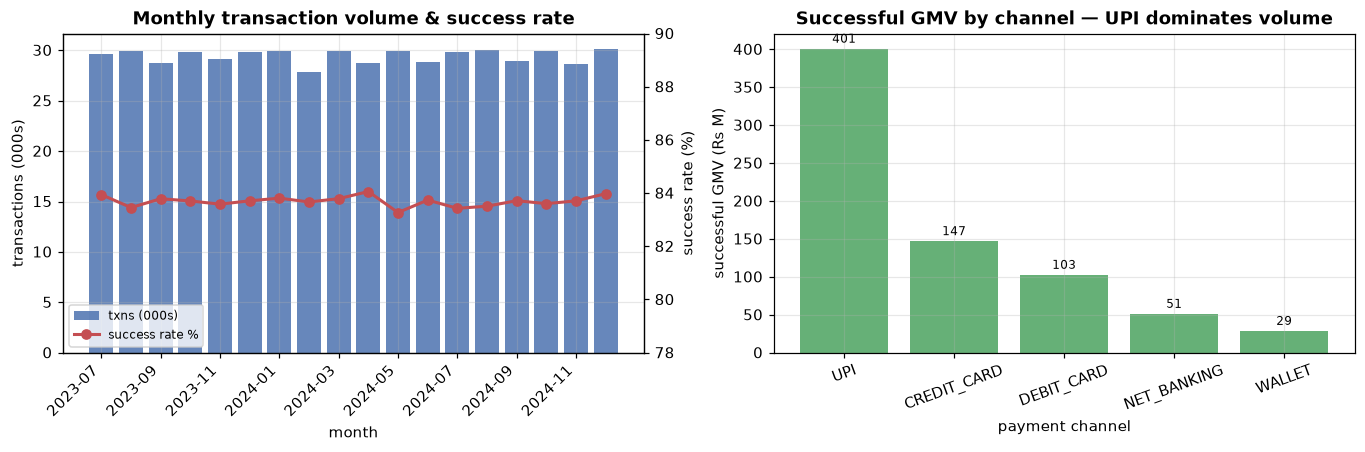

Baseline read: 530,000 attempts at 83.69% success; ~28.4% of settlement batches breach SLA; 16.21% of merchants have churned. UPI carries 55% of successful GMV but earns 0% MDR — revenue lives in cards/NetBanking.


In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.2))

x = np.arange(len(monthly))
ax1.bar(x, monthly["txns"] / 1e3, color="#4c72b0", alpha=0.85, label="txns (000s)")
ax1.set_xticks(x[::2]); ax1.set_xticklabels(monthly["ym"][::2], rotation=45, ha="right")
ax1.set_ylabel("transactions (000s)"); ax1.set_xlabel("month")
ax2b = ax1.twinx()
ax2b.plot(x, monthly["sr_pct"], color="#c44e52", marker="o", lw=2, label="success rate %")
ax2b.set_ylim(78, 90); ax2b.set_ylabel("success rate (%)"); ax2b.grid(False)
ax1.set_title("Monthly transaction volume & success rate")
h1, l1 = ax1.get_legend_handles_labels(); h2, l2 = ax2b.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="lower left", fontsize=8)

bars = ax2.bar(channel["payment_channel"], channel["gmv_success_m"], color="#55a868", alpha=0.9)
label_bars(ax2, "{:,.0f}")
ax2.set_ylabel("successful GMV (Rs M)"); ax2.set_xlabel("payment channel")
ax2.set_title("Successful GMV by channel — UPI dominates volume")
ax2.tick_params(axis="x", rotation=20)

plt.tight_layout(); plt.show()

print(f"Baseline read: {kpi['total_txns'].iloc[0]:,} attempts at {kpi['success_rate_pct'].iloc[0]:.2f}% success; "
      f"~{kpi['sla_breach_rate_pct'].iloc[0]:.1f}% of settlement batches breach SLA; "
      f"{kpi['churn_rate_pct'].iloc[0]:.2f}% of merchants have churned. "
      f"UPI carries {channel.loc[channel['payment_channel'] == 'UPI', 'gmv_success_m'].iloc[0] / channel['gmv_success_m'].sum() * 100:.0f}% of successful GMV but earns 0% MDR — revenue lives in cards/NetBanking.")

## 6 · Part 1 — KBQ 1: Issuing-Bank Latency & Switch-Degradation Profiling
Which of the 12 issuing banks drive latency and timeouts, how do PSU banks compare with private banks,
and where in the day does the switch infrastructure crack? A **p95 latency** and a **spike share**
(share of attempts ≥ 10,000 ms — the brief's 'severe switch degradation' threshold) quantify the tails.

In [10]:
bank_profile = run_sql(f"""
    SELECT b.bank_name, b.tier,
           COUNT(*)                                                      AS txns,
           {SR}                                                          AS sr_pct,
           AVG(CASE WHEN t.status = 'TIMEOUT' THEN 1.0 ELSE 0 END) * 100 AS timeout_pct,
           AVG(t.latency_ms)                                             AS avg_latency_ms,
           AVG(CASE WHEN t.latency_ms >= 10000 THEN 1.0 ELSE 0 END) * 100 AS spike_pct
    FROM fact_payment_transactions t
    JOIN dim_issuing_banks b USING (bank_id)
    GROUP BY 1, 2
    ORDER BY avg_latency_ms DESC
""")

# p95 via SQL window (SQLite has no PERCENTILE_CONT): value at rank ceil(0.95 n)
bank_p95 = run_sql("""
    WITH ranked AS (
        SELECT b.bank_name, t.latency_ms,
               ROW_NUMBER() OVER (PARTITION BY b.bank_name ORDER BY t.latency_ms) AS rn,
               COUNT(*)     OVER (PARTITION BY b.bank_name)                       AS n
        FROM fact_payment_transactions t JOIN dim_issuing_banks b USING (bank_id)
    )
    SELECT bank_name, MAX(latency_ms) AS p95_latency_ms
    FROM ranked
    WHERE rn = CAST(0.95 * n AS INTEGER) + 1
    GROUP BY bank_name
""")
bank_profile = bank_profile.merge(bank_p95, on="bank_name")
display(bank_profile)

tier_cmp = bank_profile.groupby("tier").apply(
    lambda g: pd.Series({
        "banks": len(g),
        "txns": g["txns"].sum(),
        "sr_pct": np.average(g["sr_pct"], weights=g["txns"]),
        "avg_latency_ms": np.average(g["avg_latency_ms"], weights=g["txns"]),
        "p95_latency_ms": np.average(g["p95_latency_ms"], weights=g["txns"]),
        "spike_pct": np.average(g["spike_pct"], weights=g["txns"]),
    }), include_groups=False).reindex(["TIER_1_PSU", "TIER_1_PVT", "TIER_2_PVT"])
display(tier_cmp)

,bank_name,tier,txns,sr_pct,timeout_pct,avg_latency_ms,spike_pct,p95_latency_ms
0,Bank of Baroda,TIER_1_PSU,44173,83.43,4.18,"1,442.54",1.99,7002
1,Union Bank of India,TIER_1_PSU,44215,83.46,4.04,"1,440.07",1.95,7007
2,Punjab National Bank,TIER_1_PSU,44105,83.64,4.13,"1,440.07",2.00,7088
3,State Bank of India,TIER_1_PSU,44334,83.66,3.98,"1,425.79",1.82,6864
4,Canara Bank,TIER_1_PSU,44258,83.98,4.04,"1,416.69",1.83,6907
5,Kotak Mahindra Bank,TIER_1_PVT,43936,83.63,4.16,"1,328.60",1.48,4106
6,Yes Bank,TIER_2_PVT,44097,83.77,4.13,"1,322.03",1.46,4114
7,HDFC Bank,TIER_1_PVT,44144,83.66,4.05,"1,321.71",1.52,4086
8,Federal Bank,TIER_2_PVT,44332,83.75,4.05,"1,320.56",1.54,4077
9,ICICI Bank,TIER_1_PVT,44121,83.64,4.07,"1,318.99",1.46,4106


,banks,txns,sr_pct,avg_latency_ms,p95_latency_ms,spike_pct
tier,,,,,,
TIER_1_PSU,5.00,"221,085.00",83.63,"1,433.02","6,973.47",1.92
TIER_1_PVT,4.00,"176,548.00",83.68,"1,321.58","4,097.23",1.47
TIER_2_PVT,3.00,"132,367.00",83.80,"1,317.80","4,079.37",1.47


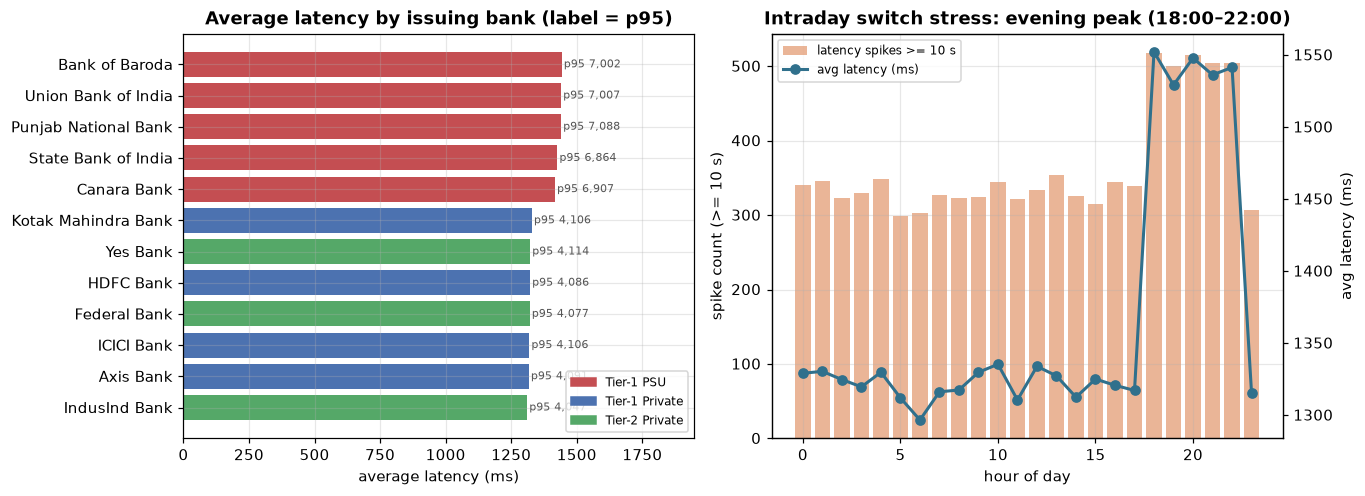

PSU banks run ~+8% avg latency vs Tier-1 private (1433 vs 1322 ms) and a spike share of 1.92% vs 1.47%. Worst three banks: Bank of Baroda, Union Bank of India, Punjab National Bank.
Evening 18-22h: avg latency 1541 ms vs 1321 ms off-peak (+17%); spikes average 508/hr vs 329/hr off-peak — an intraday capacity ceiling, not a success-rate dip (SR moves < 1 pp across hours).


In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.6))

bp = bank_profile.sort_values("avg_latency_ms")
colors = bp["tier"].map({"TIER_1_PSU": "#c44e52", "TIER_1_PVT": "#4c72b0", "TIER_2_PVT": "#55a868"})
ax1.barh(bp["bank_name"], bp["avg_latency_ms"], color=colors)
for y, (lat, p95) in enumerate(zip(bp["avg_latency_ms"], bp["p95_latency_ms"])):
    ax1.text(lat + 8, y, f"p95 {p95:,.0f}", va="center", fontsize=7.5, color="#555")
ax1.set_xlim(0, bp["avg_latency_ms"].max() * 1.35)
ax1.set_xlabel("average latency (ms)")
ax1.set_title("Average latency by issuing bank (label = p95)")
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in ["#c44e52", "#4c72b0", "#55a868"]]
ax1.legend(handles, ["Tier-1 PSU", "Tier-1 Private", "Tier-2 Private"], fontsize=8, loc="lower right")

hourly = run_sql(f"""
    SELECT CAST(SUBSTR(t.txn_timestamp, 12, 2) AS INTEGER) AS hour,
           COUNT(*)                                        AS txns,
           {SR}                                            AS sr_pct,
           AVG(t.latency_ms)                               AS avg_latency_ms,
           SUM(CASE WHEN t.latency_ms >= 10000 THEN 1 ELSE 0 END) AS spikes
    FROM fact_payment_transactions t
    GROUP BY 1 ORDER BY 1
""")
ax2b = ax2.twinx()
ax2.bar(hourly["hour"], hourly["spikes"], color="#dd8452", alpha=0.6, label="latency spikes >= 10 s")
ax2.set_xlabel("hour of day"); ax2.set_ylabel("spike count (>= 10 s)")
ax2b.plot(hourly["hour"], hourly["avg_latency_ms"], color="#30708c", marker="o", lw=2,
          label="avg latency (ms)")
ax2b.set_ylabel("avg latency (ms)"); ax2b.grid(False)
ax2.set_title("Intraday switch stress: evening peak (18:00–22:00)")
h1, l1 = ax2.get_legend_handles_labels(); h2, l2 = ax2b.get_legend_handles_labels()
ax2.legend(h1 + h2, l1 + l2, fontsize=8, loc="upper left")

plt.tight_layout(); plt.show()

psu = tier_cmp.loc["TIER_1_PSU"]; pvt = tier_cmp.loc["TIER_1_PVT"]
evening = hourly[hourly["hour"].between(18, 22)]
offpeak = hourly[~hourly["hour"].between(18, 22)]
print(f"PSU banks run ~{psu['avg_latency_ms'] / pvt['avg_latency_ms'] - 1:+.0%} avg latency vs Tier-1 private "
      f"({psu['avg_latency_ms']:.0f} vs {pvt['avg_latency_ms']:.0f} ms) and a spike share of "
      f"{psu['spike_pct']:.2f}% vs {pvt['spike_pct']:.2f}%. Worst three banks: "
      f"{', '.join(bank_profile.head(3)['bank_name'])}.")
print(f"Evening 18-22h: avg latency {evening['avg_latency_ms'].mean():.0f} ms vs {offpeak['avg_latency_ms'].mean():.0f} ms off-peak "
      f"({evening['avg_latency_ms'].mean() / offpeak['avg_latency_ms'].mean() - 1:+.0%}); "
      f"spikes average {evening['spikes'].mean():,.0f}/hr vs {offpeak['spikes'].mean():,.0f}/hr off-peak — "
      f"an intraday capacity ceiling, not a success-rate dip (SR moves < 1 pp across hours).")

## 7 · Part 1 — KBQ 2: Error-Code Pareto — Infrastructure vs User-Side
Of every failed attempt, *who* is to blame? Upstream banking infrastructure
(`ERR_BANK_TIMEOUT`, `ERR_SWITCH_UNAVAILABLE`, `ERR_NPCI_DEGRADED`) vs user-side issues
(`ERR_INSUFFICIENT_FUNDS`, `ERR_AUTH_FAILED`). Note the accounting rule kept throughout:
`status = 'TIMEOUT'` rows and `error_code = 'ERR_BANK_TIMEOUT'` rows are **different counts** —
the Pareto works on error codes of all non-SUCCESS attempts.

In [12]:
pareto = run_sql("""
    SELECT error_code,
           CASE WHEN error_code IN ('ERR_BANK_TIMEOUT', 'ERR_SWITCH_UNAVAILABLE', 'ERR_NPCI_DEGRADED')
                THEN 'Infrastructure'
                ELSE 'User-side' END AS fault_domain,
           COUNT(*) AS failures
    FROM fact_payment_transactions
    WHERE status <> 'SUCCESS'
    GROUP BY 1, 2
    ORDER BY failures DESC
""")
total_failures = pareto["failures"].sum()
pareto["share_pct"] = pareto["failures"] / total_failures * 100
pareto["cumulative_pct"] = pareto["share_pct"].cumsum()
display(pareto)

domain_split = pareto.groupby("fault_domain")["failures"].sum()
infra_share = domain_split.get("Infrastructure", 0) / total_failures * 100

# TIMEOUT status vs BANK_TIMEOUT error code — deliberate, documented distinction
timeout_status = run_sql("SELECT COUNT(*) n FROM fact_payment_transactions WHERE status = 'TIMEOUT'")
bank_timeout_on_failed = run_sql("""
    SELECT COUNT(*) n FROM fact_payment_transactions
    WHERE status = 'FAILED' AND error_code = 'ERR_BANK_TIMEOUT'
""")
# USER_DROPPED <-> ERR_AUTH_FAILED pairing check
pairing = run_sql("""
    SELECT status, error_code, COUNT(*) n FROM fact_payment_transactions
    WHERE status <> 'SUCCESS' GROUP BY 1, 2 ORDER BY n DESC
""")
display(pairing)

,error_code,fault_domain,failures,share_pct,cumulative_pct
0,ERR_BANK_TIMEOUT,Infrastructure,39178,45.33,45.33
1,ERR_AUTH_FAILED,User-side,28445,32.91,78.23
2,ERR_INSUFFICIENT_FUNDS,User-side,15785,18.26,96.50
3,ERR_NPCI_DEGRADED,Infrastructure,1516,1.75,98.25
4,ERR_SWITCH_UNAVAILABLE,Infrastructure,1513,1.75,100.00


,status,error_code,n
0,TIMEOUT,ERR_BANK_TIMEOUT,21611
1,FAILED,ERR_BANK_TIMEOUT,17567
2,FAILED,ERR_INSUFFICIENT_FUNDS,15785
3,FAILED,ERR_AUTH_FAILED,15646
4,USER_DROPPED,ERR_AUTH_FAILED,12799
5,FAILED,ERR_NPCI_DEGRADED,1516
6,FAILED,ERR_SWITCH_UNAVAILABLE,1513


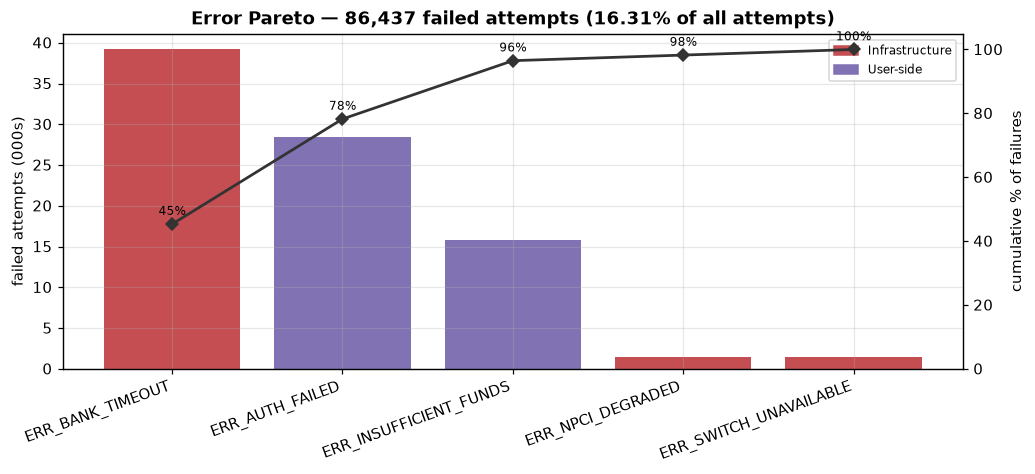

Failed attempts: 86,437 (16.31% of 530,000). Upstream infrastructure = 48.83% of failures, led by ERR_BANK_TIMEOUT (45.3%); user-side = 51.17%. Every USER_DROPPED attempt (12,799) carries ERR_AUTH_FAILED 1:1 — an authentication experience failure, not a switch fault; the same code also marks 15,646 FAILED attempts.
Accounting note: status='TIMEOUT' rows = 21,611 vs ERR_BANK_TIMEOUT on FAILED rows = 17,567 - the two counts overlap only conceptually and are never summed.


In [13]:
fig, ax = plt.subplots(figsize=(9.5, 4.4))
x = np.arange(len(pareto))
colors = ["#c44e52" if d == "Infrastructure" else "#8172b3" for d in pareto["fault_domain"]]
ax.bar(x, pareto["failures"] / 1e3, color=colors)
ax.set_xticks(x); ax.set_xticklabels(pareto["error_code"], rotation=20, ha="right")
ax.set_ylabel("failed attempts (000s)")
axb = ax.twinx()
axb.plot(x, pareto["cumulative_pct"], color="#333", marker="D", lw=1.8)
axb.set_ylim(0, 105); axb.set_ylabel("cumulative % of failures"); axb.grid(False)
for xi, ci in zip(x, pareto["cumulative_pct"]):
    axb.annotate(f"{ci:.0f}%", (xi, ci), xytext=(0, 6), textcoords="offset points",
                 ha="center", fontsize=8)
ax.set_title(f"Error Pareto — {total_failures:,} failed attempts "
             f"({total_failures / kpi['total_txns'].iloc[0] * 100:.2f}% of all attempts)")
handles = [plt.Rectangle((0, 0), 1, 1, color="#c44e52"), plt.Rectangle((0, 0), 1, 1, color="#8172b3")]
ax.legend(handles, ["Infrastructure", "User-side"], fontsize=8)

plt.tight_layout(); plt.show()

auth_failed_rows = int(pairing.loc[(pairing["status"] == "USER_DROPPED")
                                   & (pairing["error_code"] == "ERR_AUTH_FAILED"), "n"].iloc[0])
auth_failed_on_failed = int(pairing.loc[(pairing["status"] == "FAILED")
                                        & (pairing["error_code"] == "ERR_AUTH_FAILED"), "n"].iloc[0])
print(f"Failed attempts: {total_failures:,} ({total_failures / kpi['total_txns'].iloc[0]:.2%} of "
      f"{int(kpi['total_txns'].iloc[0]):,}). Upstream infrastructure = {infra_share:.2f}% of failures, led by "
      f"ERR_BANK_TIMEOUT ({pareto.loc[pareto['error_code'] == 'ERR_BANK_TIMEOUT', 'share_pct'].iloc[0]:.1f}%); "
      f"user-side = {100 - infra_share:.2f}%. Every USER_DROPPED attempt ({auth_failed_rows:,}) carries "
      f"ERR_AUTH_FAILED 1:1 — an authentication experience failure, not a switch fault; the same code also "
      f"marks {auth_failed_on_failed:,} FAILED attempts.")
print(f"Accounting note: status='TIMEOUT' rows = {int(timeout_status['n'].iloc[0]):,} vs "
      f"ERR_BANK_TIMEOUT on FAILED rows = {int(bank_timeout_on_failed['n'].iloc[0]):,} - "
      f"the two counts overlap only conceptually and are never summed.")

## 8 · Part 2 — KBQ 3: Settlement Delay Diagnostics by Contracted SLA Cycle
Merchants contract payouts T+0 … T+3. We measure the SLA breach rate and delay severity per cycle,
the delay-day distribution, the monthly breach trend (stability check that later justifies
run-rate annualization), and an **MCC × cycle breach matrix** (multivariate diagnostic #1).

In [14]:
cycle = run_sql("""
    SELECT m.settlement_cycle_sla                                        AS sla_cycle,
           COUNT(*)                                                      AS batches,
           AVG(s.sla_breach_flag * 1.0) * 100                            AS breach_pct,
           AVG(s.settlement_delay_days)                                  AS avg_delay_days,
           AVG(CASE WHEN s.sla_breach_flag = 1
                    THEN s.settlement_delay_days END)                    AS avg_delay_if_breach_days
    FROM fact_merchant_settlements s
    JOIN dim_merchants m USING (merchant_id)
    GROUP BY 1 ORDER BY 1
""")
display(cycle)

delay_dist = run_sql("""
    SELECT settlement_delay_days AS delay_days, COUNT(*) AS batches
    FROM fact_merchant_settlements GROUP BY 1 ORDER BY 1
""")
display(delay_dist)

monthly_breach = run_sql("""
    SELECT SUBSTR(settlement_batch_date, 1, 7) AS batch_month,
           COUNT(*)                            AS batches,
           AVG(sla_breach_flag * 1.0) * 100    AS breach_pct
    FROM fact_merchant_settlements
    WHERE settlement_batch_date <= '2024-12-31'
    GROUP BY 1 ORDER BY 1
""")
print(f"Monthly breach-rate range (2023-07..2024-12): "
      f"{monthly_breach['breach_pct'].min():.1f}% – {monthly_breach['breach_pct'].max():.1f}%  → flat, no seasonality.")

,sla_cycle,batches,breach_pct,avg_delay_days,avg_delay_if_breach_days
0,T_PLUS_0,4311,12.22,0.14,1.14
1,T_PLUS_1,66643,11.96,0.14,1.17
2,T_PLUS_2,42227,49.56,0.85,1.72
3,T_PLUS_3,11819,51.74,0.93,1.80


,delay_days,batches
0,0,89460
1,1,20062
2,2,10419
3,3,4116
4,4,943


Monthly breach-rate range (2023-07..2024-12): 27.7% – 29.5%  → flat, no seasonality.


settlement_cycle_sla,T_PLUS_0,T_PLUS_1,T_PLUS_2,T_PLUS_3
mcc_category,,,,
EDTECH,10.42,11.72,47.11,43.73
E_COMMERCE,12.46,12.16,49.57,53.30
FOOD_DINING,13.55,11.84,49.24,52.97
GAMING_ENTERTAINMENT,11.58,11.96,49.50,53.06
HEALTHCARE_RETAIL,11.94,12.20,47.82,45.99
TRAVEL_HOSPITALITY,14.29,11.91,49.91,48.48
UTILITIES_BILLS,9.29,11.76,51.69,54.28


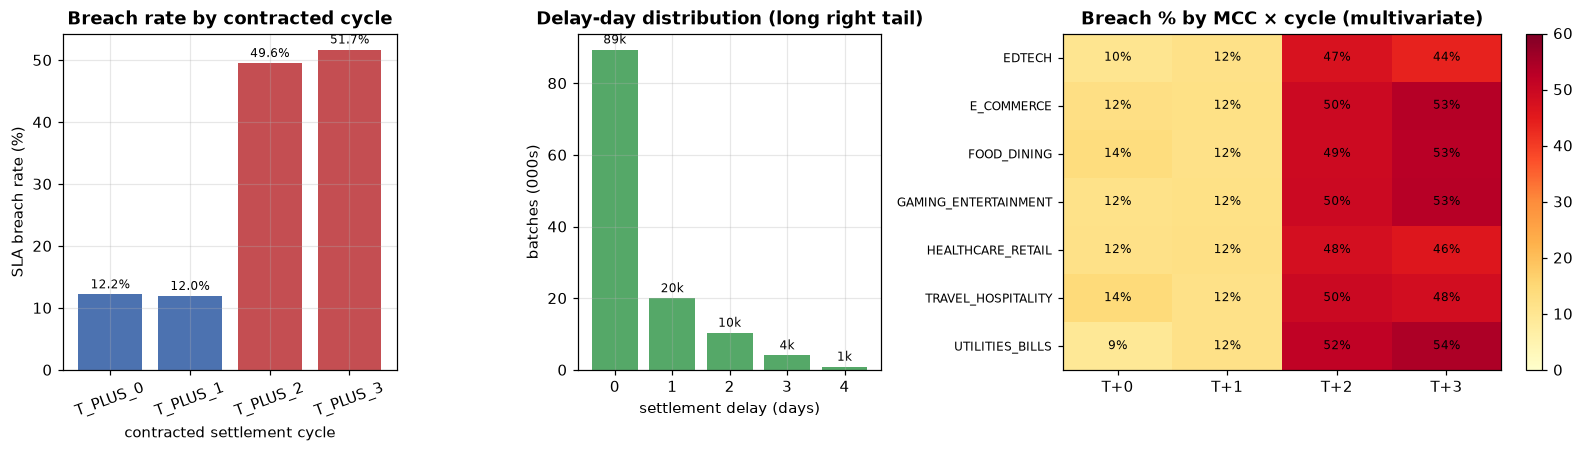

T+0/T+1 contracts breach at ~12.2% while T+2/T+3 contracts breach at ~50% — a 4x structural gap. Breached batches still arrive ~1.5 days late on average, and the MCC × cycle matrix shows the T+2/T+3 breach failure is platform-wide (every MCC), not a category quirk.


In [15]:
mcc_matrix = run_sql("""
    SELECT m.mcc_category, m.settlement_cycle_sla,
           AVG(s.sla_breach_flag * 1.0) * 100 AS breach_pct
    FROM fact_merchant_settlements s
    JOIN dim_merchants m USING (merchant_id)
    GROUP BY 1, 2
""").pivot(index="mcc_category", columns="settlement_cycle_sla", values="breach_pct")
mcc_matrix = mcc_matrix.reindex(columns=["T_PLUS_0", "T_PLUS_1", "T_PLUS_2", "T_PLUS_3"])
display(mcc_matrix)

fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.2),
                         gridspec_kw={"width_ratios": [1.1, 1.0, 1.6]})

ax = axes[0]
ax.bar(cycle["sla_cycle"], cycle["breach_pct"],
       color=["#4c72b0", "#4c72b0", "#c44e52", "#c44e52"])
label_bars(ax, "{:,.1f}%")
ax.set_ylabel("SLA breach rate (%)"); ax.set_xlabel("contracted settlement cycle")
ax.set_title("Breach rate by contracted cycle")
ax.tick_params(axis="x", rotation=20)

ax = axes[1]
ax.bar(delay_dist["delay_days"], delay_dist["batches"] / 1e3, color="#55a868")
label_bars(ax, "{:,.0f}k")
ax.set_xlabel("settlement delay (days)"); ax.set_ylabel("batches (000s)")
ax.set_title("Delay-day distribution (long right tail)")

ax = axes[2]
im = ax.imshow(mcc_matrix.values, cmap="YlOrRd", aspect="auto",
               vmin=0, vmax=max(60, mcc_matrix.values.max()))
ax.set_xticks(range(len(mcc_matrix.columns)))
ax.set_xticklabels([c.replace("T_PLUS_", "T+") for c in mcc_matrix.columns])
ax.set_yticks(range(len(mcc_matrix.index))); ax.set_yticklabels(mcc_matrix.index, fontsize=8)
for i in range(mcc_matrix.shape[0]):
    for j in range(mcc_matrix.shape[1]):
        ax.text(j, i, f"{mcc_matrix.values[i, j]:.0f}%", ha="center", va="center", fontsize=8)
ax.set_title("Breach % by MCC × cycle (multivariate)")
ax.grid(False)
plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout(); plt.show()

t2 = cycle.loc[cycle["sla_cycle"] == "T_PLUS_2", "breach_pct"].iloc[0]
t0 = cycle.loc[cycle["sla_cycle"] == "T_PLUS_0", "breach_pct"].iloc[0]
print(f"T+0/T+1 contracts breach at ~{t0:.1f}% while T+2/T+3 contracts breach at ~{t2:.0f}% — a 4x structural gap. "
      f"Breached batches still arrive ~{cycle['avg_delay_if_breach_days'].mean():.1f} days late on average, "
      f"and the MCC × cycle matrix shows the T+2/T+3 breach failure is platform-wide (every MCC), not a category quirk.")

## 9 · Part 2 — KBQ 4: Settlement Friction vs Merchant Attrition (Multivariate Diagnostic #2)
Does *recurrent* settlement breach actually precede churn? We segment merchants by **SLA-breach
exposure bucket** (share of their batches breaching) × **tier**, compare churn rates within the
covered population (coverage shown not to bias churn above), and decompose churn reasons.

In [16]:
churn_tier = run_sql("""
    SELECT merchant_tier, COUNT(*) AS merchants,
           SUM(churn_date IS NOT NULL) AS churned,
           AVG(churn_date IS NOT NULL) * 100 AS churn_pct
    FROM dim_merchants GROUP BY 1
""").set_index("merchant_tier").reindex(TIER_ORDER).reset_index()
display(churn_tier)

churn_matrix = run_sql(MERCHANT_BREACH_CTE + """
    SELECT merchant_tier, breach_bucket,
           COUNT(*)                          AS merchants,
           SUM(is_churned)                   AS churned,
           AVG(is_churned * 1.0) * 100       AS churn_pct
    FROM classified
    GROUP BY 1, 2
""")
BUCKET_ORDER = ["0%", "0-10%", "10-25%", ">25%"]
churn_pivot = churn_matrix.pivot(index="merchant_tier", columns="breach_bucket",
                                 values="churn_pct").reindex(TIER_ORDER)[BUCKET_ORDER]
churn_n = churn_matrix.pivot(index="merchant_tier", columns="breach_bucket",
                             values="merchants").reindex(TIER_ORDER)[BUCKET_ORDER]
display(churn_pivot)
display(churn_n)

smb = churn_pivot.loc["SMB"]
smb_ratio = smb[">25%"] / smb["0-10%"]
mm = churn_pivot.loc["MID_MARKET"]
print(f"SMB churn: >25%-breach bucket {smb['>25%']:.2f}% vs low-breach 0-10% bucket {smb['0-10%']:.2f}% "
      f"→ {smb_ratio:.1f}x more likely to churn under recurrent breaches. "
      f"MID_MARKET shows the same direction ({mm['>25%']:.2f}% vs {mm['0-10%']:.2f}%), ENTERPRISE barely moves — "
      f"small merchants absorb the working-capital shock.")

,merchant_tier,merchants,churned,churn_pct
0,ENTERPRISE,696,22,3.16
1,MID_MARKET,2349,174,7.41
2,SMB,5455,1182,21.67


breach_bucket,0%,0-10%,10-25%,>25%
merchant_tier,,,,
ENTERPRISE,0.00,1.33,2.50,NaN
MID_MARKET,0.00,4.14,1.52,14.43
SMB,0.00,10.12,8.76,32.66


breach_bucket,0%,0-10%,10-25%,>25%
merchant_tier,,,,
ENTERPRISE,2.00,75.00,120.00,NaN
MID_MARKET,1.00,145.00,330.00,201.00
SMB,1.00,257.00,491.00,894.00


SMB churn: >25%-breach bucket 32.66% vs low-breach 0-10% bucket 10.12% → 3.2x more likely to churn under recurrent breaches. MID_MARKET shows the same direction (14.43% vs 4.14%), ENTERPRISE barely moves — small merchants absorb the working-capital shock.


merchant_tier,ENTERPRISE,MID_MARKET,SMB
churn_reason,,,
COMPETITOR_SWITCH,6,33,227
HIGH_FAILURE_RATE,4,40,281
HIGH_MDR_FEES,12,24,93
SETTLEMENT_DELAY,0,77,581


,merchant_tier,avg_tenure_days,churned
0,ENTERPRISE,144.36,22
1,MID_MARKET,147.65,174
2,SMB,148.43,1182


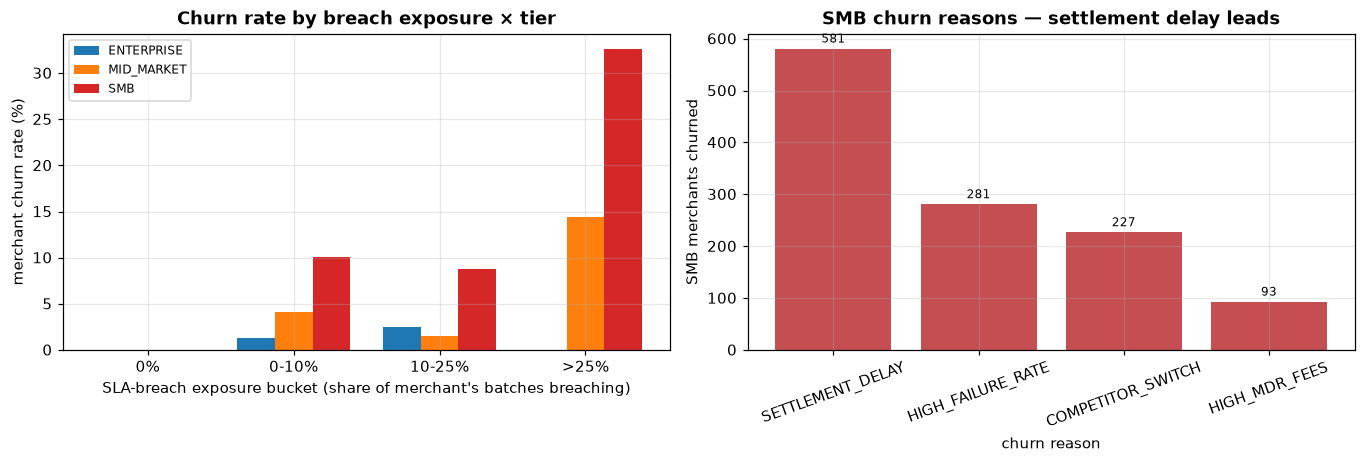

581 of 1182 SMB churners (49%) cite SETTLEMENT_DELAY as the reason — the exposure gradient above is the mechanism, and churned merchants leave after ~147 days on platform regardless of tier.


In [17]:
reasons = run_sql("""
    SELECT merchant_tier, churn_reason, COUNT(*) AS merchants
    FROM dim_merchants
    WHERE churn_date IS NOT NULL
    GROUP BY 1, 2
""")
reasons_smb = reasons[reasons["merchant_tier"] == "SMB"].sort_values("merchants", ascending=False)
display(reasons.pivot(index="churn_reason", columns="merchant_tier",
                      values="merchants").fillna(0).astype(int))

tenure = run_sql("""
    SELECT merchant_tier,
           AVG(JULIANDAY(churn_date) - JULIANDAY(onboarding_date)) AS avg_tenure_days,
           COUNT(*) AS churned
    FROM dim_merchants
    WHERE churn_date IS NOT NULL
    GROUP BY 1
""")
display(tenure)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.3))

x = np.arange(len(BUCKET_ORDER)); w = 0.26
for i, tier in enumerate(TIER_ORDER):
    vals = churn_pivot.loc[tier]
    ax1.bar(x + (i - 1) * w, vals, width=w, label=tier, color=TIER_COLORS[tier])
ax1.set_xticks(x); ax1.set_xticklabels(BUCKET_ORDER)
ax1.set_xlabel("SLA-breach exposure bucket (share of merchant's batches breaching)")
ax1.set_ylabel("merchant churn rate (%)")
ax1.set_title("Churn rate by breach exposure × tier")
ax1.legend(fontsize=8)

ax2.bar(reasons_smb["churn_reason"], reasons_smb["merchants"], color="#c44e52")
label_bars(ax2)
ax2.set_xlabel("churn reason"); ax2.set_ylabel("SMB merchants churned")
ax2.set_title("SMB churn reasons — settlement delay leads")
ax2.tick_params(axis="x", rotation=20)

plt.tight_layout(); plt.show()

smb_delay_churn = int(reasons_smb.loc[reasons_smb["churn_reason"] == "SETTLEMENT_DELAY", "merchants"].iloc[0])
smb_churn_total = int(churn_tier.loc[churn_tier["merchant_tier"] == "SMB", "churned"].iloc[0])
print(f"{smb_delay_churn} of {smb_churn_total} SMB churners ({smb_delay_churn / smb_churn_total * 100:.0f}%) cite "
      f"SETTLEMENT_DELAY as the reason — the exposure gradient above is the mechanism, and churned merchants "
      f"leave after ~{tenure['avg_tenure_days'].mean():.0f} days on platform regardless of tier.")

## 10 · Part 3 — KBQ 5 & 6: Dynamic SLA Smart-Routing — A/B Lift & Latency Mitigation
**Benchmark to verify: +8.50 pp absolute success-rate lift (accepted band 8.30–8.70 pp),
baseline ~79.5% → ~88.0%.** We compute the A/B comparison, test lift stability across tiers and
channels (multivariate diagnostic #3), then quantify the latency reduction from bypassing degraded switches
(multivariate diagnostic #4: route × bank).

In [18]:
ab = run_sql(f"""
    SELECT t.is_routed_via_dynamic_sla AS routed,
           COUNT(*) AS txns,
           {SR}     AS sr_pct,
           AVG(t.latency_ms) AS avg_latency_ms
    FROM fact_payment_transactions t
    GROUP BY 1 ORDER BY 1
""")
sr_standard = ab.loc[ab["routed"] == 0, "sr_pct"].iloc[0]
sr_dynamic = ab.loc[ab["routed"] == 1, "sr_pct"].iloc[0]
lift = sr_dynamic - sr_standard
display(ab)

# stability of the lift across segments
lift_tier = run_sql(f"""
    SELECT m.merchant_tier, t.is_routed_via_dynamic_sla AS routed,
           COUNT(*) AS txns, {SR} AS sr_pct
    FROM fact_payment_transactions t JOIN dim_merchants m USING (merchant_id)
    GROUP BY 1, 2
""").pivot(index="merchant_tier", columns="routed", values="sr_pct").reindex(TIER_ORDER)
lift_tier["lift_pp"] = lift_tier[1] - lift_tier[0]

lift_channel = run_sql(f"""
    SELECT pm.payment_channel, t.is_routed_via_dynamic_sla AS routed,
           COUNT(*) AS txns, {SR} AS sr_pct
    FROM fact_payment_transactions t JOIN dim_payment_methods pm USING (payment_method_id)
    GROUP BY 1, 2
""").pivot(index="payment_channel", columns="routed", values="sr_pct")
lift_channel["lift_pp"] = lift_channel[1] - lift_channel[0]

display(lift_tier)
display(lift_channel)

print(f"SUCCESS-RATE LIFT: standard {sr_standard:.2f}% -> dynamic {sr_dynamic:.2f}% = +{lift:.2f} pp")
print(f"Benchmark check: target +8.50 pp, accepted band 8.30-8.70 pp -> "
      f"{'PASS' if 8.30 <= lift <= 8.70 else 'FAIL'}")
assert 8.30 <= lift <= 8.70, f"Routing lift {lift:.2f} pp outside accepted band 8.30-8.70 pp!"
print(f"Lift is stable across tiers (range {lift_tier['lift_pp'].min():.2f}-{lift_tier['lift_pp'].max():.2f} pp) "
      f"and channels (range {lift_channel['lift_pp'].min():.2f}-{lift_channel['lift_pp'].max():.2f} pp) — "
      f"a platform-wide engine effect, not a segment artifact.")

,routed,txns,sr_pct,avg_latency_ms
0,0,264736,79.40,"1,700.05"
1,1,265264,87.97,"1,034.86"


routed,0,1,lift_pp
merchant_tier,,,
ENTERPRISE,79.68,87.89,8.21
MID_MARKET,79.52,87.80,8.27
SMB,79.32,88.06,8.74


routed,0,1,lift_pp
payment_channel,,,
CREDIT_CARD,79.42,87.99,8.57
DEBIT_CARD,79.59,87.63,8.04
NET_BANKING,79.30,88.04,8.74
UPI,79.37,88.00,8.63
WALLET,79.30,88.49,9.18


SUCCESS-RATE LIFT: standard 79.40% -> dynamic 87.97% = +8.57 pp
Benchmark check: target +8.50 pp, accepted band 8.30-8.70 pp -> PASS
Lift is stable across tiers (range 8.21-8.74 pp) and channels (range 8.04-9.18 pp) — a platform-wide engine effect, not a segment artifact.


,routed,avg_latency_ms,p50_ms,p95_ms
0,0,"1,700.05",1054,7336
1,1,"1,034.86",570,3793


routed,0,1,improvement_ms
bank_name,,,
Bank of Baroda,"1,793.69","1,096.42",697.28
Canara Bank,"1,792.06","1,043.43",748.63
Union Bank of India,"1,784.46","1,101.02",683.43
State Bank of India,"1,780.72","1,072.41",708.31
Punjab National Bank,"1,778.92","1,104.51",674.41
Kotak Mahindra Bank,"1,655.51",999.93,655.58


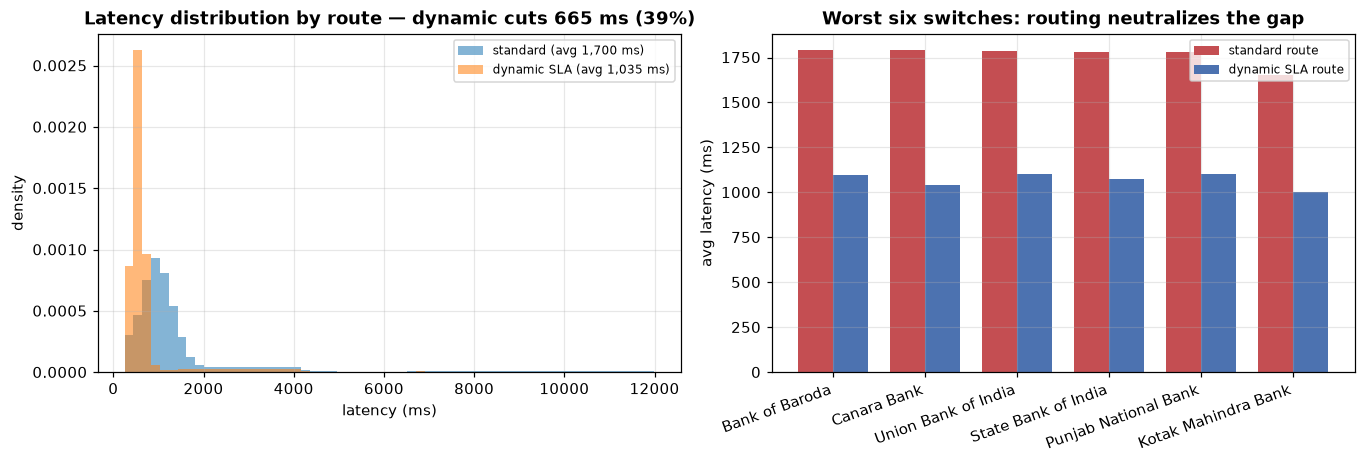

Dynamic routing cuts average latency 1,700 -> 1,035 ms (-665 ms, 39%) and p95 7,336 -> 3,793 ms. On every degraded PSU switch the dynamic route claws back 666 ms on average.


In [19]:
# latency mitigation: route-level stats + p50/p95 via SQL window
latency_route = run_sql("""
    WITH ranked AS (
        SELECT is_routed_via_dynamic_sla AS routed, latency_ms,
               ROW_NUMBER() OVER (PARTITION BY is_routed_via_dynamic_sla ORDER BY latency_ms) AS rn,
               COUNT(*)     OVER (PARTITION BY is_routed_via_dynamic_sla)                AS n
        FROM fact_payment_transactions
    )
    SELECT routed,
           MAX(CASE WHEN rn = CAST(0.50 * n AS INTEGER) + 1 THEN latency_ms END) AS p50_ms,
           MAX(CASE WHEN rn = CAST(0.95 * n AS INTEGER) + 1 THEN latency_ms END) AS p95_ms
    FROM ranked GROUP BY routed
""")
latency_route = ab[["routed", "avg_latency_ms"]].merge(latency_route, on="routed")
display(latency_route)

lat_reduction = (latency_route.loc[latency_route["routed"] == 0, "avg_latency_ms"].iloc[0]
                 - latency_route.loc[latency_route["routed"] == 1, "avg_latency_ms"].iloc[0])

# route x bank: does dynamic routing neutralize the worst switches?
route_bank = run_sql("""
    SELECT b.bank_name, b.tier, t.is_routed_via_dynamic_sla AS routed, AVG(t.latency_ms) AS avg_latency_ms
    FROM fact_payment_transactions t JOIN dim_issuing_banks b USING (bank_id)
    GROUP BY 1, 2, 3
""").pivot(index="bank_name", columns="routed", values="avg_latency_ms")
route_bank["improvement_ms"] = route_bank[0] - route_bank[1]
route_bank = route_bank.sort_values(0, ascending=False)
display(route_bank.head(6))

lat_samples = run_sql("SELECT latency_ms, is_routed_via_dynamic_sla AS routed FROM fact_payment_transactions")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.3))

ax1.hist(lat_samples.loc[lat_samples["routed"] == 0, "latency_ms"], bins=60,
         alpha=0.55, density=True, label=f"standard (avg {latency_route.loc[0, 'avg_latency_ms']:,.0f} ms)")
ax1.hist(lat_samples.loc[lat_samples["routed"] == 1, "latency_ms"], bins=60,
         alpha=0.55, density=True, label=f"dynamic SLA (avg {latency_route.loc[1, 'avg_latency_ms']:,.0f} ms)")
ax1.set_xlabel("latency (ms)"); ax1.set_ylabel("density")
ax1.set_title(f"Latency distribution by route — dynamic cuts {lat_reduction:,.0f} ms "
              f"({lat_reduction / latency_route.loc[0, 'avg_latency_ms'] * 100:.0f}%)")
ax1.legend(fontsize=8)

top6 = route_bank.head(6)
x = np.arange(len(top6)); w = 0.38
ax2.bar(x - w / 2, top6[0], width=w, label="standard route", color="#c44e52")
ax2.bar(x + w / 2, top6[1], width=w, label="dynamic SLA route", color="#4c72b0")
ax2.set_xticks(x); ax2.set_xticklabels(top6.index, rotation=20, ha="right")
ax2.set_ylabel("avg latency (ms)")
ax2.set_title("Worst six switches: routing neutralizes the gap")
ax2.legend(fontsize=8)

plt.tight_layout(); plt.show()

print(f"Dynamic routing cuts average latency {latency_route.loc[0, 'avg_latency_ms']:,.0f} -> "
      f"{latency_route.loc[1, 'avg_latency_ms']:,.0f} ms (-{lat_reduction:,.0f} ms, "
      f"{lat_reduction / latency_route.loc[0, 'avg_latency_ms'] * 100:.0f}%) and p95 "
      f"{latency_route.loc[0, 'p95_ms']:,.0f} -> {latency_route.loc[1, 'p95_ms']:,.0f} ms. "
      f"On every degraded PSU switch the dynamic route claws back "
      f"{route_bank['improvement_ms'].mean():,.0f} ms on average.")

## 11 · Part 4 — KBQ 7: MDR Revenue Economics by Tier × Channel
Two accounting lenses, kept distinct: **realized** MDR = fee actually deducted on settled batches
(`fact_merchant_settlements`); **potential** MDR = successful transaction volume × contracted
`mdr_rate_pct` (transactions × dim). UPI's 0% MDR makes volume and revenue diverge sharply.

In [20]:
realized_tier = run_sql("""
    SELECT m.merchant_tier,
           COUNT(*)                                      AS batches,
           SUM(s.gross_volume_inr) / 1e6                 AS gpv_m,
           SUM(s.net_mdr_deducted_inr) / 1e6             AS mdr_m,
           100 * SUM(s.net_mdr_deducted_inr) / SUM(s.gross_volume_inr) AS blended_mdr_pct
    FROM fact_merchant_settlements s JOIN dim_merchants m USING (merchant_id)
    GROUP BY 1
""").set_index("merchant_tier").reindex(TIER_ORDER).reset_index()
display(realized_tier)

potential_channel = run_sql("""
    SELECT pm.payment_channel,
           SUM(t.amount_inr) / 1e6                          AS gmv_success_m,
           100.0 * SUM(t.amount_inr) /
               (SELECT SUM(amount_inr) FROM fact_payment_transactions WHERE status = 'SUCCESS') AS gmv_share_pct,
           SUM(t.amount_inr * pm.mdr_rate_pct / 100) / 1e6  AS mdr_potential_m,
           MIN(pm.mdr_rate_pct) AS rate_min, MAX(pm.mdr_rate_pct) AS rate_max
    FROM fact_payment_transactions t JOIN dim_payment_methods pm USING (payment_method_id)
    WHERE t.status = 'SUCCESS'
    GROUP BY 1 ORDER BY mdr_potential_m DESC
""")
display(potential_channel)

tier_channel = run_sql("""
    SELECT m.merchant_tier, pm.payment_channel,
           SUM(t.amount_inr * pm.mdr_rate_pct / 100) / 1e6 AS mdr_potential_m
    FROM fact_payment_transactions t
    JOIN dim_payment_methods pm USING (payment_method_id)
    JOIN dim_merchants m USING (merchant_id)
    WHERE t.status = 'SUCCESS'
    GROUP BY 1, 2
""").pivot(index="merchant_tier", columns="payment_channel",
           values="mdr_potential_m").reindex(TIER_ORDER)
display(tier_channel)

monthly_mdr = run_sql("""
    SELECT SUBSTR(actual_settlement_date, 1, 7) AS settle_month,
           SUM(net_mdr_deducted_inr) / 1e6      AS realized_mdr_m
    FROM fact_merchant_settlements
    WHERE actual_settlement_date <= '2024-12-31'
    GROUP BY 1 ORDER BY 1
""")

,merchant_tier,batches,gpv_m,mdr_m,blended_mdr_pct
0,ENTERPRISE,9801,17.07,0.22,1.30
1,MID_MARKET,33606,58.38,0.76,1.30
2,SMB,81593,142.27,1.85,1.30


,payment_channel,gmv_success_m,gmv_share_pct,mdr_potential_m,rate_min,rate_max
0,CREDIT_CARD,147.03,20.13,2.53,1.20,2.40
1,DEBIT_CARD,102.60,14.05,0.85,0.40,0.90
2,NET_BANKING,51.15,7.00,0.78,1.50,1.65
3,WALLET,28.70,3.93,0.32,1.10,1.15
4,UPI,400.76,54.88,0.00,0.00,0.00


payment_channel,CREDIT_CARD,DEBIT_CARD,NET_BANKING,UPI,WALLET
merchant_tier,,,,,
ENTERPRISE,0.21,0.07,0.07,0.00,0.03
MID_MARKET,0.70,0.23,0.21,0.00,0.09
SMB,1.63,0.54,0.50,0.00,0.21


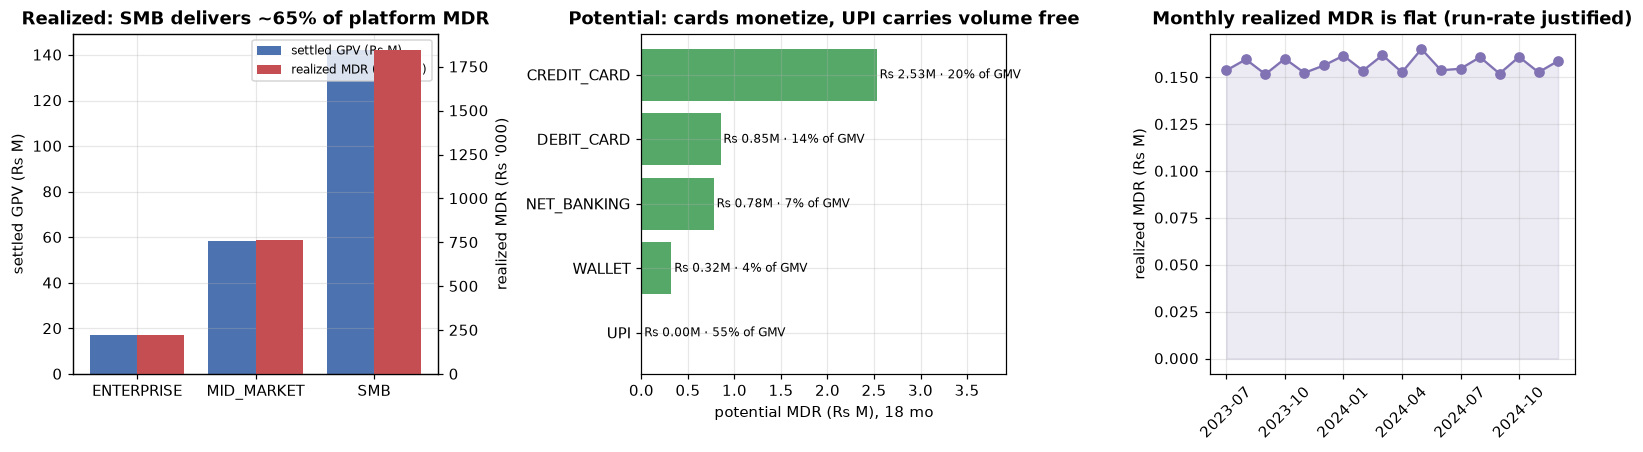

Realized MDR (18 mo): Rs 2.831M on settled GPV of Rs 217.72M (blended 1.30%). SMB contributes 65% of platform MDR — losing SMB merchants to settlement failures is a direct revenue event.
Channel mix: UPI = 55% of successful GMV at 0% MDR; credit cards generate 56% of potential MDR from ~20% of GMV (rates 1.2-2.4%) — monetization is card-concentrated.


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.2))

ax = axes[0]
x = np.arange(len(realized_tier))
ax.bar(x - 0.2, realized_tier["gpv_m"], width=0.4, label="settled GPV (Rs M)", color="#4c72b0")
axb = ax.twinx()
axb.bar(x + 0.2, realized_tier["mdr_m"] * 1000, width=0.4, label="realized MDR (Rs '000)", color="#c44e52")
axb.grid(False)
ax.set_xticks(x); ax.set_xticklabels(realized_tier["merchant_tier"])
ax.set_ylabel("settled GPV (Rs M)"); axb.set_ylabel("realized MDR (Rs '000)")
ax.set_title("Realized: SMB delivers ~65% of platform MDR")
h1, l1 = ax.get_legend_handles_labels(); h2, l2 = axb.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, fontsize=8, loc="upper right")

ax = axes[1]
pc = potential_channel.sort_values("mdr_potential_m")
ax.barh(pc["payment_channel"], pc["mdr_potential_m"], color="#55a868")
for y, (m, share) in enumerate(zip(pc["mdr_potential_m"], pc["gmv_share_pct"])):
    ax.text(m + 0.03, y, f"Rs {m:,.2f}M · {share:.0f}% of GMV", va="center", fontsize=8)
ax.set_xlim(0, pc["mdr_potential_m"].max() * 1.55)
ax.set_xlabel("potential MDR (Rs M), 18 mo")
ax.set_title("Potential: cards monetize, UPI carries volume free")

ax = axes[2]
ax.plot(monthly_mdr["settle_month"], monthly_mdr["realized_mdr_m"], marker="o", color="#8172b3")
ax.fill_between(monthly_mdr["settle_month"], monthly_mdr["realized_mdr_m"], alpha=0.15, color="#8172b3")
ax.set_xticks(monthly_mdr["settle_month"][::3])
ax.tick_params(axis="x", rotation=45)
ax.set_ylabel("realized MDR (Rs M)")
ax.set_title("Monthly realized MDR is flat (run-rate justified)")

plt.tight_layout(); plt.show()

smb_mdr_share = realized_tier.loc[realized_tier["merchant_tier"] == "SMB", "mdr_m"].iloc[0] / \
    realized_tier["mdr_m"].sum() * 100
upi_gmv_share = potential_channel.loc[potential_channel["payment_channel"] == "UPI", "gmv_share_pct"].iloc[0]
cc_mdr_share = potential_channel.loc[potential_channel["payment_channel"] == "CREDIT_CARD", "mdr_potential_m"].iloc[0] / \
    potential_channel["mdr_potential_m"].sum() * 100
total_mdr = realized_tier["mdr_m"].sum()
print(f"Realized MDR (18 mo): Rs {total_mdr:,.3f}M on settled GPV of Rs {realized_tier['gpv_m'].sum():,.2f}M "
      f"(blended {100 * total_mdr / realized_tier['gpv_m'].sum():.2f}%). "
      f"SMB contributes {smb_mdr_share:.0f}% of platform MDR — losing SMB merchants to settlement failures is a "
      f"direct revenue event.")
print(f"Channel mix: UPI = {upi_gmv_share:.0f}% of successful GMV at 0% MDR; credit cards generate "
      f"{cc_mdr_share:.0f}% of potential MDR from ~20% of GMV (rates 1.2-2.4%) — monetization is card-concentrated.")

## 12 · Part 4 — KBQ 8: Protected Volume — What Eliminating Settlement Delays Saves
Sizing the annualized GMV and MDR preserved by fixing settlement breaches for **at-risk SMB merchants**
(> 25% of their batches breaching). Two scenarios: the **at-stake ceiling** (the whole segment's run-rate)
and an **excess-churn scenario** (churn reverts from the high-breach rate to the low-breach SMB baseline).
All figures annualize the trailing 18-month run-rate × 12/18 — justified by the flat monthly breach
(≈ 28%) and MDR trend verified in Part 2 / KBQ 7.

,metric,value
0,at-risk SMB merchants (>25% batches breaching),894
1,observed churn in segment,32.66%
2,low-breach SMB baseline churn (0-10%),10.12%
3,excess churn pp,22.55 pp
4,saveable merchants (excess model),202
5,segment annualized GMV (at-stake ceiling),Rs 51.6M / yr
6,segment annualized realized MDR (ceiling),Rs 0.669M / yr
7,protected GMV (excess-churn scenario),Rs 11.6M / yr
8,protected MDR (excess-churn scenario),Rs 0.151M / yr


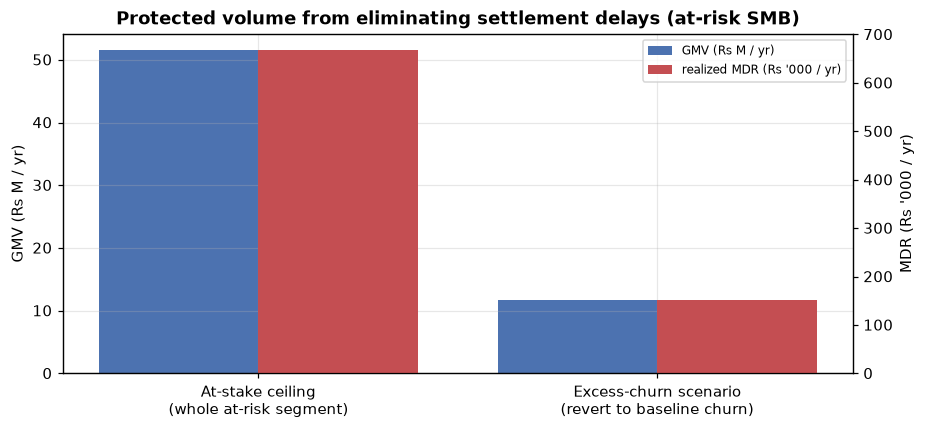

Assumptions: (1) trailing 18-month run-rate x 12/18 annualization — flat breach (~28%/mo) and MDR trend verified; (2) fixing breaches moves segment churn to the low-breach baseline (10.1%); (3) retained merchants sustain segment-average GPV/MDR economics; (4) no credit taken for replacement acquisition (conservative).


In [22]:
at_risk = run_sql(MERCHANT_BREACH_CTE + """
    SELECT COUNT(*)                                          AS merchants,
           SUM(is_churned)                                   AS churned,
           AVG(is_churned * 1.0) * 100                       AS churn_pct,
           SUM(gpv_inr) / 1e6                                AS gpv_18m_m,
           SUM(mdr_inr) / 1e6                                AS mdr_18m_m
    FROM classified
    WHERE merchant_tier = 'SMB' AND breach_bucket = '>25%'
""")
n_risk = int(at_risk["merchants"].iloc[0])
risk_churn_pct = at_risk["churn_pct"].iloc[0]
risk_gpv_annual_m = at_risk["gpv_18m_m"].iloc[0] * 12 / 18
risk_mdr_annual_m = at_risk["mdr_18m_m"].iloc[0] * 12 / 18

baseline = run_sql(MERCHANT_BREACH_CTE + """
    SELECT AVG(is_churned * 1.0) * 100 AS churn_pct
    FROM classified
    WHERE merchant_tier = 'SMB' AND breach_bucket = '0-10%'
""")
baseline_churn_pct = baseline["churn_pct"].iloc[0]
excess_pp = risk_churn_pct - baseline_churn_pct
saveable = n_risk * excess_pp / 100
# merchants saveable = segment size x excess churn rate; protected volume = segment run-rate x same share
protected_share = excess_pp / 100
protected_gpv_annual_m = risk_gpv_annual_m * protected_share
protected_mdr_annual_m = risk_mdr_annual_m * protected_share

display(pd.DataFrame({
    "metric": ["at-risk SMB merchants (>25% batches breaching)", "observed churn in segment",
               "low-breach SMB baseline churn (0-10%)", "excess churn pp", "saveable merchants (excess model)",
               "segment annualized GMV (at-stake ceiling)", "segment annualized realized MDR (ceiling)",
               "protected GMV (excess-churn scenario)", "protected MDR (excess-churn scenario)"],
    "value": [f"{n_risk:,}", f"{risk_churn_pct:.2f}%", f"{baseline_churn_pct:.2f}%",
              f"{excess_pp:.2f} pp", f"{saveable:,.0f}",
              f"Rs {risk_gpv_annual_m:,.1f}M / yr", f"Rs {risk_mdr_annual_m:.3f}M / yr",
              f"Rs {protected_gpv_annual_m:,.1f}M / yr", f"Rs {protected_mdr_annual_m:.3f}M / yr"],
}))

fig, ax = plt.subplots(figsize=(8.5, 4))
scen = ["At-stake ceiling\n(whole at-risk segment)", "Excess-churn scenario\n(revert to baseline churn)"]
gpv_vals = [risk_gpv_annual_m, protected_gpv_annual_m]
mdr_vals = [risk_mdr_annual_m * 1000, protected_mdr_annual_m * 1000]
x = np.arange(2)
ax.bar(x - 0.2, gpv_vals, width=0.4, label="GMV (Rs M / yr)", color="#4c72b0")
axb = ax.twinx()
axb.bar(x + 0.2, mdr_vals, width=0.4, label="realized MDR (Rs '000 / yr)", color="#c44e52")
axb.grid(False)
ax.set_xticks(x); ax.set_xticklabels(scen)
ax.set_ylabel("GMV (Rs M / yr)"); axb.set_ylabel("MDR (Rs '000 / yr)")
ax.set_title("Protected volume from eliminating settlement delays (at-risk SMB)")
h1, l1 = ax.get_legend_handles_labels(); h2, l2 = axb.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, fontsize=8, loc="upper right")

plt.tight_layout(); plt.show()

print(f"Assumptions: (1) trailing 18-month run-rate x 12/18 annualization — flat breach (~28%/mo) and MDR trend "
      f"verified; (2) fixing breaches moves segment churn to the low-breach baseline ({baseline_churn_pct:.1f}%); "
      f"(3) retained merchants sustain segment-average GPV/MDR economics; (4) no credit taken for replacement "
      f"acquisition (conservative).")

## 13 · Findings → 5 Prioritized Recommendations & Executive Summary
Each recommendation follows **Finding → Business Problem → Recommendation → Expected Impact**,
with impact quantified from this notebook's own outputs and assumptions stated inline.
★ = top-3 priority for the executive deck.

In [23]:
from IPython.display import Markdown

smb_merchants = int(churn_tier.loc[churn_tier["merchant_tier"] == "SMB", "merchants"].iloc[0])
upi_gmv_18m = potential_channel.loc[potential_channel["payment_channel"] == "UPI", "gmv_success_m"].iloc[0]
avg_ticket = kpi["gmv_attempted_m"].iloc[0] / kpi["total_txns"].iloc[0] * 1e6

exec_md = Markdown(f"""\
### Recommendations (prioritized)

**★ 1. Reroute settlement-bound payouts for breach-exposed SMB merchants (T+2/T+3 contracts)**
* **Finding:** T+2/T+3 cycles breach SLA ~{cycle.loc[cycle['sla_cycle'] == 'T_PLUS_2', 'breach_pct'].iloc[0]:.0f}–{cycle.loc[cycle['sla_cycle'] == 'T_PLUS_3', 'breach_pct'].iloc[0]:.0f}% vs ~{t0:.0f}% on T+0/T+1; SMB merchants in the >25%-breach bucket churn at {risk_churn_pct:.1f}% vs {baseline_churn_pct:.1f}% for low-breach peers ({smb_ratio:.1f}×).
* **Problem:** Recurrent payout delays create SMB working-capital stress; {smb_delay_churn} SMB churners ({smb_delay_churn / smb_churn_total * 100:.0f}% of SMB churn) cite settlement delay — and SMB pays {smb_mdr_share:.0f}% of platform MDR.
* **Recommendation:** Guarantee T+1 payouts for breach-exposed SMB via a liquidity buffer / early-settlement program; cap new SMB onboarding on T+2/T+3 contracts.
* **Expected impact:** Protects **Rs {protected_gpv_annual_m:,.0f}M GMV / Rs {protected_mdr_annual_m * 1000:,.0f}K MDR per year** (excess-churn scenario; assumptions in KBQ 8: run-rate annualization, churn reversion to {baseline_churn_pct:.1f}% baseline, no replacement credit). *Assumption:* net funding cost of the buffer < protected MDR.

**★ 2. Shift smart-routing to 100% of traffic and prioritize PSU bank de-congestion in the evening window**
* **Finding:** Dynamic SLA routing lifts success **+{lift:.2f} pp** ({sr_standard:.2f}% → {sr_dynamic:.2f}%, within the 8.30–8.70 band) and cuts latency {lat_reduction:,.0f} ms ({lat_reduction / latency_route.loc[0, 'avg_latency_ms'] * 100:.0f}%); PSU switches run ~{psu['avg_latency_ms'] / pvt['avg_latency_ms'] - 1:+.0%} latency vs private and evening 18–22 h spike counts run ~{evening['spikes'].mean() / offpeak['spikes'].mean() - 1:+.0%}.
* **Problem:** {total_failures:,} failed attempts ({total_failures / kpi['total_txns'].iloc[0] * 100:.1f}% of volume), {infra_share:.0f}% infrastructure-attributable; every failed attempt risks drop-off on zero-fee UPI and MDR loss on cards.
* **Recommendation:** Default-route all traffic through the dynamic SLA engine; add explicit evening (18–22 h) capacity throttling toward private-switch rails for PSU-bound volume; publish a bank-switch SLA scorecard and renegotiate with the worst three ({', '.join(bank_profile.head(3)['bank_name'])}).
* **Expected impact:** Closing the remaining routed/unrouted gap on ~{ab.loc[ab['routed'] == 0, 'txns'].iloc[0]:,.0f} still-unrouted attempts is worth ≈ **{ab.loc[ab['routed'] == 0, 'txns'].iloc[0] * lift / 100:,.0f} recovered successful transactions per 18 months** (≈ Rs {ab.loc[ab['routed'] == 0, 'txns'].iloc[0] * lift / 100 * kpi['gmv_attempted_m'].iloc[0] / kpi['total_txns'].iloc[0]:,.1f}M GMV; *assumes lifted attempts convert at the platform average ticket*).

**★ 3. Launch a save-desk for high-breach SMB merchants before they hit the churn cliff**
* **Finding:** Churn is not linear in breach exposure — it inflects above 25% breach share ({smb['>25%']:.1f}% vs {smb['10-25%']:.1f}% in 10–25%), and churners leave after ~{tenure['avg_tenure_days'].mean():.0f} days.
* **Problem:** By the time a merchant churns, ~5 months of recoverable relationship have elapsed; silent attrition of SMB merchants erodes the {smb_mdr_share:.0f}% MDR core.
* **Recommendation:** Trigger an outreach/save offer (fee holiday, priority settlement) when a merchant's rolling 30-day breach share crosses 20%; track save-rate as a KPI.
* **Expected impact:** Moving even one-quarter of the {saveable:,.0f} excess-churn merchants back protects ≈ **Rs {protected_gpv_annual_m / 4:,.1f}M GMV / Rs {protected_mdr_annual_m * 1000 / 4:,.0f}K MDR per year** on top of Rec 1's systemic fix (*assumes offer uptake ≥ 50% and same unit economics*).

**4. Rebalance MDR monetization toward the UPI installed base (productized pricing, not fee hikes)**
* **Finding:** UPI carries {upi_gmv_share:.0f}% of successful GMV at 0% MDR; credit cards yield {cc_mdr_share:.0f}% of potential MDR from ~20% of GMV; blended realized take-rate is flat at ~1.30%.
* **Problem:** Revenue concentration in cards leaves the platform exposed to card-MDR regulation/competition, while the massive UPI base monetizes at zero.
* **Recommendation:** Monetize UPI merchants via value-added rails (instant settlement for a flat monthly fee, working-capital offers, premium analytics) rather than per-transaction UPI MDR.
* **Expected impact:** Attaching a Rs 1,000/month instant-settlement SaaS to 10% of the {smb_merchants:,} SMB merchants ≈ **Rs {smb_merchants * 0.10 * 1000 * 12 / 1e6:,.2f}M incremental annual revenue** (*assumes 10% attach rate at Rs 1,000/mo; no transaction-fee change*).

**5. Fix the evening capacity ceiling with switch-level SLOs**
* **Finding:** 18:00–22 h latency averages ~{evening['avg_latency_ms'].mean():.0f} ms vs ~{offpeak['avg_latency_ms'].mean():.0f} ms off-peak with ~{evening['spikes'].mean() / offpeak['spikes'].mean() - 1:+.0%} spike volume; success rate stays flat — the system degrades on *experience*, not just completion.
* **Problem:** Latency spikes during peak commerce hours degrade checkout UX invisibly (no SR signal) and precede infrastructure failures.
* **Recommendation:** Set per-switch evening SLOs (p95 < 3 s), pre-scale NPCI/switch connectivity 17–23 h, and add automated traffic shedding to healthy switches when p95 breaches.
* **Expected impact:** Evening hours carry ~{5 / 24 * 100:.0f}% of daily volume; a 1% abandonment improvement on that peak traffic is worth ≈ **Rs {monthly['txns'].mean() * 5 / 24 * 0.01 * avg_ticket / 1e6:,.2f}M GMV/month** (*assumes peak-hour volume share ∝ hours-of-day and 1% checkout-abandonment sensitivity to peak latency*).

---

### Executive summary

| Dimension | Evidence (this notebook) | So what |
|---|---|---|
| Scale | {kpi['total_txns'].iloc[0]:,} txns · {kpi['merchants'].iloc[0]:,} merchants · Rs {total_mdr:,.2f}M realized MDR (18 mo) | SMB = {smb_mdr_share:.0f}% of MDR — SMB retention *is* the P&L |
| Gateway | PSU latency +{psu['avg_latency_ms'] / pvt['avg_latency_ms'] - 1:.0%} vs private; {infra_share:.0f}% of failures infrastructure-side | Smart-routing lift +{lift:.2f} pp is already proven — finish the rollout |
| Settlement | T+2/T+3 breach ~{t2:.0f}% vs ~{t0:.0f}% on T+0/T+1; monthly breach flat ≈ 28% | Structural, seasonal-free → fixable with liquidity + contract design |
| Churn | SMB churn {churn_tier.loc[churn_tier['merchant_tier'] == 'SMB', 'churn_pct'].iloc[0]:.1f}% vs ENT {churn_tier.loc[churn_tier['merchant_tier'] == 'ENTERPRISE', 'churn_pct'].iloc[0]:.1f}%; >25%-breach bucket churns {smb_ratio:.1f}× low-breach peers | Breach exposure is the controllable churn driver |
| Prize | Rs {risk_gpv_annual_m:,.0f}M annual GMV / Rs {risk_mdr_annual_m:.2f}M annual MDR at stake in at-risk SMB; Rs {protected_gpv_annual_m:,.1f}M / Rs {protected_mdr_annual_m * 1000:,.0f}K protected in the excess-churn scenario | Top-3 recommendations target exactly this pool |
""")
ipy_display(exec_md)

### Recommendations (prioritized)

**★ 1. Reroute settlement-bound payouts for breach-exposed SMB merchants (T+2/T+3 contracts)**
* **Finding:** T+2/T+3 cycles breach SLA ~50–52% vs ~12% on T+0/T+1; SMB merchants in the >25%-breach bucket churn at 32.7% vs 10.1% for low-breach peers (3.2×).
* **Problem:** Recurrent payout delays create SMB working-capital stress; 581 SMB churners (49% of SMB churn) cite settlement delay — and SMB pays 65% of platform MDR.
* **Recommendation:** Guarantee T+1 payouts for breach-exposed SMB via a liquidity buffer / early-settlement program; cap new SMB onboarding on T+2/T+3 contracts.
* **Expected impact:** Protects **Rs 12M GMV / Rs 151K MDR per year** (excess-churn scenario; assumptions in KBQ 8: run-rate annualization, churn reversion to 10.1% baseline, no replacement credit). *Assumption:* net funding cost of the buffer < protected MDR.

**★ 2. Shift smart-routing to 100% of traffic and prioritize PSU bank de-congestion in the evening window**
* **Finding:** Dynamic SLA routing lifts success **+8.57 pp** (79.40% → 87.97%, within the 8.30–8.70 band) and cuts latency 665 ms (39%); PSU switches run ~+8% latency vs private and evening 18–22 h spike counts run ~+55%.
* **Problem:** 86,437 failed attempts (16.3% of volume), 49% infrastructure-attributable; every failed attempt risks drop-off on zero-fee UPI and MDR loss on cards.
* **Recommendation:** Default-route all traffic through the dynamic SLA engine; add explicit evening (18–22 h) capacity throttling toward private-switch rails for PSU-bound volume; publish a bank-switch SLA scorecard and renegotiate with the worst three (Bank of Baroda, Union Bank of India, Punjab National Bank).
* **Expected impact:** Closing the remaining routed/unrouted gap on ~264,736 still-unrouted attempts is worth ≈ **22,681 recovered successful transactions per 18 months** (≈ Rs 37.3M GMV; *assumes lifted attempts convert at the platform average ticket*).

**★ 3. Launch a save-desk for high-breach SMB merchants before they hit the churn cliff**
* **Finding:** Churn is not linear in breach exposure — it inflects above 25% breach share (32.7% vs 8.8% in 10–25%), and churners leave after ~147 days.
* **Problem:** By the time a merchant churns, ~5 months of recoverable relationship have elapsed; silent attrition of SMB merchants erodes the 65% MDR core.
* **Recommendation:** Trigger an outreach/save offer (fee holiday, priority settlement) when a merchant's rolling 30-day breach share crosses 20%; track save-rate as a KPI.
* **Expected impact:** Moving even one-quarter of the 202 excess-churn merchants back protects ≈ **Rs 2.9M GMV / Rs 38K MDR per year** on top of Rec 1's systemic fix (*assumes offer uptake ≥ 50% and same unit economics*).

**4. Rebalance MDR monetization toward the UPI installed base (productized pricing, not fee hikes)**
* **Finding:** UPI carries 55% of successful GMV at 0% MDR; credit cards yield 56% of potential MDR from ~20% of GMV; blended realized take-rate is flat at ~1.30%.
* **Problem:** Revenue concentration in cards leaves the platform exposed to card-MDR regulation/competition, while the massive UPI base monetizes at zero.
* **Recommendation:** Monetize UPI merchants via value-added rails (instant settlement for a flat monthly fee, working-capital offers, premium analytics) rather than per-transaction UPI MDR.
* **Expected impact:** Attaching a Rs 1,000/month instant-settlement SaaS to 10% of the 5,455 SMB merchants ≈ **Rs 6.55M incremental annual revenue** (*assumes 10% attach rate at Rs 1,000/mo; no transaction-fee change*).

**5. Fix the evening capacity ceiling with switch-level SLOs**
* **Finding:** 18:00–22 h latency averages ~1541 ms vs ~1321 ms off-peak with ~+55% spike volume; success rate stays flat — the system degrades on *experience*, not just completion.
* **Problem:** Latency spikes during peak commerce hours degrade checkout UX invisibly (no SR signal) and precede infrastructure failures.
* **Recommendation:** Set per-switch evening SLOs (p95 < 3 s), pre-scale NPCI/switch connectivity 17–23 h, and add automated traffic shedding to healthy switches when p95 breaches.
* **Expected impact:** Evening hours carry ~21% of daily volume; a 1% abandonment improvement on that peak traffic is worth ≈ **Rs 0.10M GMV/month** (*assumes peak-hour volume share ∝ hours-of-day and 1% checkout-abandonment sensitivity to peak latency*).

---

### Executive summary

| Dimension | Evidence (this notebook) | So what |
|---|---|---|
| Scale | 530,000 txns · 8,500 merchants · Rs 2.83M realized MDR (18 mo) | SMB = 65% of MDR — SMB retention *is* the P&L |
| Gateway | PSU latency +8% vs private; 49% of failures infrastructure-side | Smart-routing lift +8.57 pp is already proven — finish the rollout |
| Settlement | T+2/T+3 breach ~50% vs ~12% on T+0/T+1; monthly breach flat ≈ 28% | Structural, seasonal-free → fixable with liquidity + contract design |
| Churn | SMB churn 21.7% vs ENT 3.2%; >25%-breach bucket churns 3.2× low-breach peers | Breach exposure is the controllable churn driver |
| Prize | Rs 52M annual GMV / Rs 0.67M annual MDR at stake in at-risk SMB; Rs 11.6M / Rs 151K protected in the excess-churn scenario | Top-3 recommendations target exactly this pool |
